<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1I8kDikouqpH4hf7JBiSYAeNT2IO52T-T" width=600 height=480/></p>
<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Generative adversarial networks</b></h3>



В этом домашнем задании вы обучите GAN генерировать лица людей и посмотрите на то, как можно оценивать качество генерации

In [ ]:
!pip install -qq umap-learn

In [ ]:
import os
import zipfile
import torchvision.utils as vutils
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as tt
import torch
import torch.nn as nn
import torch.optim as optim
import cv2
from tqdm.notebook import tqdm
from torchvision.utils import save_image
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
import umap
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from PIL import Image
import os


%matplotlib inline

sns.set(style='darkgrid', font_scale=1.2)

## Часть 1. Подготовка данных (1 балл)

В качестве обучающей выборки возьмем часть датасета [Flickr Faces](https://github.com/NVlabs/ffhq-dataset), который содержит изображения лиц людей в высоком разрешении (1024х1024). Оригинальный датасет очень большой, поэтому мы возьмем его часть. Скачать датасет можно [здесь](https://www.kaggle.com/datasets/tommykamaz/faces-dataset-small?resource=download-directory) и  [здесь](https://drive.google.com/file/d/1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x/view?usp=drive_link)

In [ ]:
!gdown --id 1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x


/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x
From (redirected): https://drive.google.com/uc?id=1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x&confirm=t&uuid=909514e1-b19b-4f6e-8874-60df2ebf561c
To: /content/archive.zip
100% 4.28G/4.28G [01:31<00:00, 46.7MB/s]


In [ ]:
zip_file = '/content/archive.zip'
extract_folder = '/content'

if os.path.exists(zip_file):
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(extract_folder)
    print(f"Архив успешно распакован в папку: '{extract_folder}'")
else:
    print(f"Ошибка: Файл '{zip_file}' не найден. Проверьте имя файла.")


Архив успешно распакован в папку: '/content'


Давайте загрузим наши изображения. Напишите функцию, которая строит DataLoader для изображений, при этом меняя их размер до нужного значения (размер 1024 слишком большой, поэтому мы рекомендуем взять размер 128 либо немного больше)

In [ ]:
class FlatImageDataset(Dataset):
    """Загружает все изображения из папки без вложенных подпапок."""
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        # Собираем все файлы с расширениями .png, .jpg, .jpeg
        self.images = [os.path.join(root, f) for f in os.listdir(root)
                       if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if len(self.images) == 0:
            raise FileNotFoundError(f"Нет изображений в папке {root}")
        print(f"Найдено {len(self.images)} изображений в {root}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        img = Image.open(img_path).convert('RGB')  # всегда RGB
        if self.transform:
            img = self.transform(img)
        # Возвращаем фиктивную метку (0), т.к. классы не нужны
        return img, 0

def get_dataloader(image_size, batch_size, data_path='/content/faces_dataset_small'):
    """
    Builds dataloader for training data from a flat folder (no subfolders).
    """
    transform = tt.Compose([
        tt.Resize((image_size, image_size)),
        tt.ToTensor(),
        tt.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])

    dataset = FlatImageDataset(root=data_path, transform=transform)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True,
                            num_workers=2, pin_memory=True)
    return dataloader


In [ ]:
image_size = 128

#TODO: build dataloader and transfer it to device

batch_size = 64
dataloader = get_dataloader(image_size, batch_size)

print(f"Total images: {len(dataloader.dataset)}")
print(f"Batches per epoch: {len(dataloader)}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Найдено 3143 изображений в /content/faces_dataset_small
Total images: 3143
Batches per epoch: 50
Using device: cpu


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


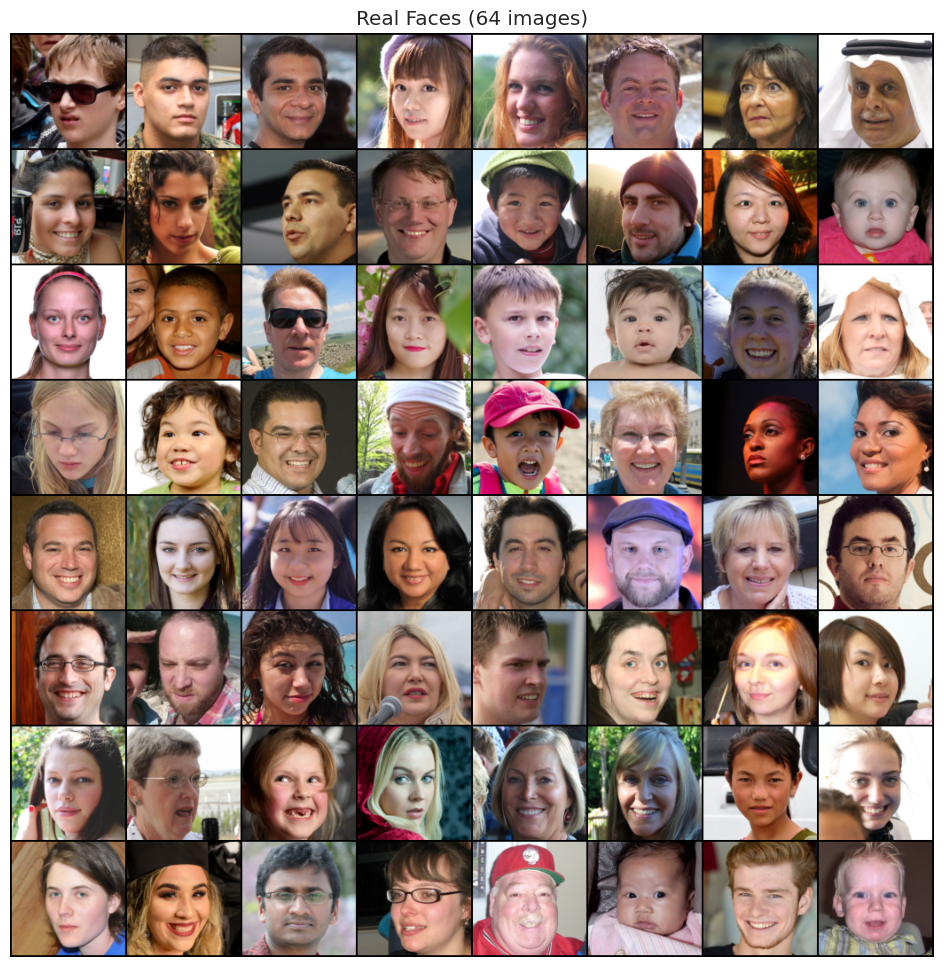

In [ ]:

real_batch = next(iter(dataloader))
real_images, _ = real_batch


def denorm(img_tensor):
    return (img_tensor + 1) / 2.0


plt.figure(figsize=(12, 12))
plt.imshow(vutils.make_grid(denorm(real_images[:64]), nrow=8, padding=2).permute(1,2,0))
plt.axis('off')
plt.title("Real Faces (64 images)")
plt.show()

## Часть 2. Построение и обучение модели (4 балла)

Сконструируйте генератор и дискриминатор. Помните, что:
* дискриминатор принимает на вход изображение (тензор размера `3 x image_size x image_size`) и выдает вероятность того, что изображение настоящее (тензор размера 1)

* генератор принимает на вход тензор шумов размера `latent_size x 1 x 1` и генерирует изображение размера `3 x image_size x image_size`



```
discriminator = ...
latent_size = ... # choose latent size

generator = ...

```



**GAN**

Generative Adversarial Nets  https://arxiv.org/pdf/1406.2661

https://github.com/eriklindernoren/PyTorch-GAN

In [ ]:
latent_size = 128

generator = nn.Sequential(
    nn.ConvTranspose2d(latent_size, 512, 4, 1, 0, bias=False),
    nn.BatchNorm2d(512),
    nn.ReLU(True),
    nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
    nn.BatchNorm2d(256),
    nn.ReLU(True),
    nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
    nn.BatchNorm2d(128),
    nn.ReLU(True),
    nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
    nn.BatchNorm2d(64),
    nn.ReLU(True),
    nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False),
    nn.BatchNorm2d(32),
    nn.ReLU(True),
    nn.ConvTranspose2d(32, 3, 4, 2, 1, bias=False),
    nn.Tanh()
)

discriminator = nn.Sequential(
    nn.Conv2d(3, 32, 4, 2, 1, bias=False),
    nn.LeakyReLU(0.2, inplace=True),
    nn.Conv2d(32, 64, 4, 2, 1, bias=False),
    nn.BatchNorm2d(64),
    nn.LeakyReLU(0.2, inplace=True),
    nn.Conv2d(64, 128, 4, 2, 1, bias=False),
    nn.BatchNorm2d(128),
    nn.LeakyReLU(0.2, inplace=True),
    nn.Conv2d(128, 256, 4, 2, 1, bias=False),
    nn.BatchNorm2d(256),
    nn.LeakyReLU(0.2, inplace=True),
    nn.Conv2d(256, 512, 4, 2, 1, bias=False),
    nn.BatchNorm2d(512),
    nn.LeakyReLU(0.2, inplace=True),
    nn.Conv2d(512, 1, 4, 1, 0, bias=False),
    nn.Flatten(),
    nn.Sigmoid()
)

In [ ]:
# Проверка генератора
test_z = torch.randn(1, latent_size, 1, 1)
fake_img = generator(test_z)
print("Generator output shape:", fake_img.shape)  # Ожидается: torch.Size([1, 3, 128, 128])

# Проверка дискриминатора
test_img = torch.randn(1, 3, 128, 128)
pred = discriminator(test_img)
print("Discriminator output shape:", pred.shape)   # Ожидается: torch.Size([1, 1])

Generator output shape: torch.Size([1, 3, 128, 128])
Discriminator output shape: torch.Size([1, 1])


Перейдем теперь к обучению нашего GANа. Алгоритм обучения следующий:
1. Учим дискриминатор:
  * берем реальные изображения и присваиваем им метку 1
  * генерируем изображения генератором и присваиваем им метку 0
  * обучаем классификатор на два класса

2. Учим генератор:
  * генерируем изображения генератором и присваиваем им метку 0
  * предсказываем дискриминаторором, реальное это изображение или нет


В качестве функции потерь берем бинарную кросс-энтропию



```
lr = 0.0001

model = {
    "discriminator": discriminator,
    "generator": generator
}

criterion = {
    "discriminator": nn.BCELoss(),
    "generator": nn.BCELOSS()
}

def fit(model, criterion, epochs, lr):
  # TODO: build optimizers and train your GAN
  pass
```



In [ ]:
lr = 0.0001

model = {
    "discriminator": discriminator,
    "generator": generator
}

criterion = {
    "discriminator": nn.BCELoss(),
    "generator": nn.BCELoss()
}

In [ ]:
def fit(model, criterion, epochs, lr):
    # Переносим модели на устройство (GPU/CPU)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model["discriminator"].to(device)
    model["generator"].to(device)

    # Оптимизаторы (Adam с beta1=0.5, как в DCGAN)
    optimizer_D = torch.optim.Adam(model["discriminator"].parameters(),
                                   lr=lr, betas=(0.5, 0.999))
    optimizer_G = torch.optim.Adam(model["generator"].parameters(),
                                   lr=lr, betas=(0.5, 0.999))

    # Для отслеживания лоссов
    losses_g = []
    losses_d = []

    for epoch in range(epochs):
        loss_d_epoch = 0.0
        loss_g_epoch = 0.0
        num_batches = 0

        for real_imgs, _ in tqdm(dataloader):  # tqdm для прогресс-бара
            real_imgs = real_imgs.to(device)
            batch_size = real_imgs.size(0)

            # Метки для BCE: real = 1, fake = 0
            real_labels = torch.ones(batch_size, 1, device=device)
            fake_labels = torch.zeros(batch_size, 1, device=device)

            # --- 1. Обучаем дискриминатор ---
            optimizer_D.zero_grad()

            # Реальные изображения
            real_outputs = model["discriminator"](real_imgs)
            loss_real = criterion["discriminator"](real_outputs, real_labels)

            # Фейковые изображения
            z = torch.randn(batch_size, latent_size, 1, 1, device=device)
            fake_imgs = model["generator"](z)
            fake_outputs = model["discriminator"](fake_imgs.detach())  # .detach() важен!
            loss_fake = criterion["discriminator"](fake_outputs, fake_labels)

            loss_D = loss_real + loss_fake
            loss_D.backward()
            optimizer_D.step()

            # --- 2. Обучаем генератор ---
            optimizer_G.zero_grad()

            z = torch.randn(batch_size, latent_size, 1, 1, device=device)
            fake_imgs = model["generator"](z)
            fake_outputs = model["discriminator"](fake_imgs)
            loss_G = criterion["generator"](fake_outputs, real_labels)  # хотим обмануть D!

            loss_G.backward()
            optimizer_G.step()

            # Сохраняем лоссы
            loss_d_epoch += loss_D.item()
            loss_g_epoch += loss_G.item()
            num_batches += 1

        # Усредняем лоссы за эпоху
        avg_loss_d = loss_d_epoch / num_batches
        avg_loss_g = loss_g_epoch / num_batches
        losses_d.append(avg_loss_d)
        losses_g.append(avg_loss_g)

        print(f"Epoch [{epoch+1}/{epochs}] Loss_D: {avg_loss_d:.4f} Loss_G: {avg_loss_g:.4f}")

    return losses_g, losses_d

**WGAN-GP**  Wasserstein GAN + Gradient Penalty

Improved Training of Wasserstein GANs
https://arxiv.org/pdf/1704.00028

https://github.com/caogang/wgan-gp

In [ ]:
image_size = 128
batch_size = 64
latent_size = 128
lr = 0.0001
lambda_gp = 10  # коэффициент градиентного штрафа
n_critic = 5    # сколько шагов критика на 1 шаг генератора
epochs = 50

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
generator = nn.Sequential(
    # 128 x 1 x 1 → 512 x 4 x 4
    nn.ConvTranspose2d(latent_size, 512, 4, 1, 0, bias=False),
    nn.BatchNorm2d(512),
    nn.ReLU(True),

    # 512 x 4 x 4 → 256 x 8 x 8
    nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
    nn.BatchNorm2d(256),
    nn.ReLU(True),

    # 256 x 8 x 8 → 128 x 16 x 16
    nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
    nn.BatchNorm2d(128),
    nn.ReLU(True),

    # 128 x 16 x 16 → 64 x 32 x 32
    nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
    nn.BatchNorm2d(64),
    nn.ReLU(True),

    # 64 x 32 x 32 → 32 x 64 x 64
    nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False),
    nn.BatchNorm2d(32),
    nn.ReLU(True),

    # 32 x 64 x 64 → 3 x 128 x 128
    nn.ConvTranspose2d(32, 3, 4, 2, 1, bias=False),
    nn.Tanh()
)

critic = nn.Sequential(
    # 3 x 128 x 128 → 32 x 64 x 64
    nn.Conv2d(3, 32, 4, 2, 1, bias=False),
    nn.LeakyReLU(0.2, inplace=True),

    # 32 x 64 x 64 → 64 x 32 x 32
    nn.Conv2d(32, 64, 4, 2, 1, bias=False),
    nn.BatchNorm2d(64),
    nn.LeakyReLU(0.2, inplace=True),

    # 64 x 32 x 32 → 128 x 16 x 16
    nn.Conv2d(64, 128, 4, 2, 1, bias=False),
    nn.BatchNorm2d(128),
    nn.LeakyReLU(0.2, inplace=True),

    # 128 x 16 x 16 → 256 x 8 x 8
    nn.Conv2d(128, 256, 4, 2, 1, bias=False),
    nn.BatchNorm2d(256),
    nn.LeakyReLU(0.2, inplace=True),

    # 256 x 8 x 8 → 512 x 4 x 4
    nn.Conv2d(256, 512, 4, 2, 1, bias=False),
    nn.BatchNorm2d(512),
    nn.LeakyReLU(0.2, inplace=True),

    # 512 x 4 x 4 → 1 x 1 x 1 (без Sigmoid!)
    nn.Conv2d(512, 1, 4, 1, 0, bias=False),
    nn.Flatten()

)

In [ ]:
generator.to(device)
critic.to(device)


Sequential(
  (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (1): LeakyReLU(negative_slope=0.2, inplace=True)
  (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (4): LeakyReLU(negative_slope=0.2, inplace=True)
  (5): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): LeakyReLU(negative_slope=0.2, inplace=True)
  (8): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): LeakyReLU(negative_slope=0.2, inplace=True)
  (11): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (12): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
 

In [ ]:
def compute_gradient_penalty(critic, real_imgs, fake_imgs):
    """Вычисляет градиентный штраф для WGAN-GP."""
    batch_size = real_imgs.size(0)

    # Случайное число alpha для интерполяции
    alpha = torch.rand(batch_size, 1, 1, 1, device=device)
    alpha = alpha.expand_as(real_imgs)

    # Интерполяция между реальными и фейковыми изображениями
    interpolated = alpha * real_imgs + (1 - alpha) * fake_imgs
    interpolated.requires_grad_(True)

    # Вычисляем выход критика для интерполированных изображений
    critic_interpolated = critic(interpolated)

    # Вычисляем градиенты
    gradients = torch.autograd.grad(
        outputs=critic_interpolated,
        inputs=interpolated,
        grad_outputs=torch.ones_like(critic_interpolated),
        create_graph=True,
        retain_graph=True
    )[0]

    # Норма градиента (L2)
    gradients = gradients.view(batch_size, -1)
    gradient_norm = gradients.norm(2, dim=1)

    # Штраф за отклонение от 1
    gradient_penalty = ((gradient_norm - 1) ** 2).mean()

    return gradient_penalty

optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.9))
optimizer_C = optim.Adam(critic.parameters(), lr=lr, betas=(0.5, 0.9))

losses_c = []
losses_g = []


**StyleGAN‑2**

Analyzing and Improving the Image Quality of StyleGAN  https://arxiv.org/pdf/1912.04958

https://github.com/NVlabs/stylegan2


In [ ]:

class PixelNorm(nn.Module):
    """Pixel-wise нормализация (StyleGAN-2)"""
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return x / torch.sqrt(torch.mean(x ** 2, dim=1, keepdim=True) + 1e-8)

class EqualizedConv2d(nn.Module):
    """Equalized Learning Rate для свёрточных слоёв"""
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)

        # Инициализация He
        nn.init.kaiming_normal_(self.conv.weight, a=0.2, mode='fan_in', nonlinearity='leaky_relu')
        nn.init.zeros_(self.conv.bias)

        # Коэффициент масштабирования
        self.scale = np.sqrt(2 / (in_channels * kernel_size ** 2))

    def forward(self, x):
        return self.conv(x) * self.scale

class EqualizedLinear(nn.Module):
    """Equalized Learning Rate для линейных слоёв"""
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)

        # Инициализация He
        nn.init.kaiming_normal_(self.linear.weight, a=0.2, mode='fan_in', nonlinearity='leaky_relu')
        nn.init.zeros_(self.linear.bias)

        # Коэффициент масштабирования
        self.scale = np.sqrt(2 / in_features)

    def forward(self, x):
        return self.linear(x) * self.scale

class NoiseInjection(nn.Module):
    """Инъекция шума (StyleGAN-2)"""
    def __init__(self, channels):
        super().__init__()
        self.weight = nn.Parameter(torch.zeros(1, channels, 1, 1))

    def forward(self, x):
        if self.training:
            noise = torch.randn(x.shape[0], 1, x.shape[2], x.shape[3], device=x.device)
            return x + self.weight * noise
        return x

class AdaIN(nn.Module):
    """AdaIN (Adaptive Instance Normalization)"""
    def __init__(self, channels, w_dim):
        super().__init__()
        self.instance_norm = nn.InstanceNorm2d(channels)
        self.style_scale = EqualizedLinear(w_dim, channels)
        self.style_bias = EqualizedLinear(w_dim, channels)

    def forward(self, x, w):
        x = self.instance_norm(x)
        scale = self.style_scale(w).unsqueeze(-1).unsqueeze(-1)
        bias = self.style_bias(w).unsqueeze(-1).unsqueeze(-1)
        return x * (1 + scale) + bias

class BlurLayer(nn.Module):
    """Размытие для подавления алиасинга"""
    def __init__(self, kernel=[1, 2, 1]):
        super().__init__()
        kernel = torch.tensor(kernel, dtype=torch.float32)
        kernel = kernel[:, None] * kernel[None, :]
        kernel = kernel / kernel.sum()
        self.register_buffer('kernel', kernel.view(1, 1, kernel.shape[0], kernel.shape[1]))

    def forward(self, x):
        if x.dim() == 4:
            padding = (self.kernel.shape[2] // 2, self.kernel.shape[3] // 2)
            return nn.functional.conv2d(x, self.kernel.expand(x.shape[1], 1, -1, -1), padding=padding, groups=x.shape[1])
        return x

class MappingNetwork(nn.Module):
    """Mapping Network из StyleGAN-2"""
    def __init__(self, z_dim, w_dim, num_layers=8):
        super().__init__()
        self.pixel_norm = PixelNorm()

        layers = []
        for i in range(num_layers):
            in_features = z_dim if i == 0 else w_dim
            layers.append(EqualizedLinear(in_features, w_dim))
            if i < num_layers - 1:
                layers.append(nn.LeakyReLU(0.2))

        self.mapping = nn.Sequential(*layers)

    def forward(self, z):
        z = self.pixel_norm(z)
        w = self.mapping(z)
        return w

class SynthesisBlock(nn.Module):
    """Блок синтеза изображения (StyleGAN-2)"""
    def __init__(self, in_channels, out_channels, w_dim, upsample=True):
        super().__init__()
        self.upsample = upsample
        self.blur = BlurLayer()

        # Конволюции с AdaIN
        self.conv1 = EqualizedConv2d(in_channels, out_channels, 3, padding=1)
        self.noise1 = NoiseInjection(out_channels)
        self.adain1 = AdaIN(out_channels, w_dim)

        self.conv2 = EqualizedConv2d(out_channels, out_channels, 3, padding=1)
        self.noise2 = NoiseInjection(out_channels)
        self.adain2 = AdaIN(out_channels, w_dim)

        self.activation = nn.LeakyReLU(0.2)

    def forward(self, x, w):
        if self.upsample:
            x = nn.functional.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
            x = self.blur(x)

        x = self.conv1(x)
        x = self.noise1(x)
        x = self.adain1(x, w)
        x = self.activation(x)

        x = self.conv2(x)
        x = self.noise2(x)
        x = self.adain2(x, w)
        x = self.activation(x)

        return x

class Generator(nn.Module):
    """StyleGAN-2 Generator"""
    def __init__(self, z_dim=512, w_dim=512, img_resolution=128, img_channels=3):
        super().__init__()

        # Mapping Network
        self.mapping = MappingNetwork(z_dim, w_dim)

        # Константный вход (4x4)
        self.const_input = nn.Parameter(torch.ones(1, 512, 4, 4))

        # Блоки синтеза
        self.synthesis_blocks = nn.ModuleList([
            SynthesisBlock(512, 512, w_dim, upsample=False),  # 4x4
            SynthesisBlock(512, 512, w_dim, upsample=True),   # 8x8
            SynthesisBlock(512, 512, w_dim, upsample=True),   # 16x16
            SynthesisBlock(512, 512, w_dim, upsample=True),   # 32x32
            SynthesisBlock(512, 512, w_dim, upsample=True),   # 64x64
            SynthesisBlock(512, 512, w_dim, upsample=True),   # 128x128
        ])

        # Финальная конволюция
        self.to_rgb = EqualizedConv2d(512, img_channels, 1)

        self.img_resolution = img_resolution
        self.w_dim = w_dim
        self.z_dim = z_dim

    def forward(self, z, truncation_psi=0.7):
        # Mapping
        w = self.mapping(z)

        # Truncation trick
        w_avg = w.mean(0, keepdim=True)
        w = w_avg + (w - w_avg) * truncation_psi

        # Синтез
        x = self.const_input.repeat(z.shape[0], 1, 1, 1)

        for block in self.synthesis_blocks:
            x = block(x, w)

        img = self.to_rgb(x)
        img = torch.tanh(img)  # [-1, 1]

        return img

class MinibatchStdDev(nn.Module):
    """Minibatch Standard Deviation для дискриминатора"""
    def __init__(self, group_size=4):
        super().__init__()
        self.group_size = group_size

    def forward(self, x):
        batch_size = x.shape[0]
        group_size = min(self.group_size, batch_size)

        # Вычисляем стандартное отклонение
        y = x.view(group_size, -1, x.shape[1], x.shape[2], x.shape[3])
        y = y - y.mean(0, keepdim=True)
        y = (y ** 2).mean(0)
        y = (y + 1e-8).sqrt()
        y = y.mean([1, 2, 3], keepdim=True)
        y = y.repeat(group_size, 1, x.shape[2], x.shape[3])
        return torch.cat([x, y], dim=1)

class DiscriminatorBlock(nn.Module):
    """Блок дискриминатора StyleGAN-2"""
    def __init__(self, in_channels, out_channels, downsample=True):
        super().__init__()
        self.downsample = downsample

        self.conv1 = EqualizedConv2d(in_channels, in_channels, 3, padding=1)
        self.conv2 = EqualizedConv2d(in_channels, out_channels, 3, padding=1)
        self.activation = nn.LeakyReLU(0.2)

        if downsample:
            self.down = nn.AvgPool2d(2)

    def forward(self, x):
        x = self.activation(self.conv1(x))
        x = self.activation(self.conv2(x))

        if self.downsample:
            x = self.down(x)

        return x

class Discriminator(nn.Module):
    """StyleGAN-2 Discriminator"""
    def __init__(self, img_resolution=128, img_channels=3):
        super().__init__()

        self.from_rgb = EqualizedConv2d(img_channels, 512, 1)

        # Блоки дискриминатора
        self.blocks = nn.ModuleList([
            DiscriminatorBlock(512, 512, downsample=True),  # 64x64
            DiscriminatorBlock(512, 512, downsample=True),  # 32x32
            DiscriminatorBlock(512, 512, downsample=True),  # 16x16
            DiscriminatorBlock(512, 512, downsample=True),  # 8x8
            DiscriminatorBlock(512, 512, downsample=True),  # 4x4
        ])

        self.minibatch_std = MinibatchStdDev()

        # Финальные слои
        self.final_conv = EqualizedConv2d(512 + 1, 512, 3, padding=1)
        self.final_activation = nn.LeakyReLU(0.2)
        self.final_linear = EqualizedLinear(512 * 4 * 4, 1)

    def forward(self, x):
        x = self.from_rgb(x)

        for block in self.blocks:
            x = block(x)

        x = self.minibatch_std(x)
        x = self.final_conv(x)
        x = self.final_activation(x)

        x = x.view(x.shape[0], -1)
        out = self.final_linear(x)

        return out


#   ФУНКЦИИ ДЛЯ ОБУЧЕНИЯ


def compute_gradient_penalty(discriminator, real_imgs, fake_imgs, device):
    """R1 Gradient Penalty из StyleGAN-2"""
    batch_size = real_imgs.size(0)

    # Случайное число для интерполяции
    alpha = torch.rand(batch_size, 1, 1, 1, device=device)
    interpolated = alpha * real_imgs + (1 - alpha) * fake_imgs
    interpolated.requires_grad_(True)

    # Лосс дискриминатора
    d_interpolated = discriminator(interpolated)

    # Градиенты
    gradients = torch.autograd.grad(
        outputs=d_interpolated,
        inputs=interpolated,
        grad_outputs=torch.ones_like(d_interpolated),
        create_graph=True,
        retain_graph=True
    )[0]

    gradients = gradients.view(batch_size, -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()

    return gradient_penalty

def compute_d_loss(real_pred, fake_pred):
    """Лосс дискриминатора (не-насыщающий)"""
    d_loss = fake_pred.mean() - real_pred.mean()
    return d_loss

def compute_g_loss(fake_pred):
    """Лосс генератора (не-насыщающий)"""
    g_loss = -fake_pred.mean()
    return g_loss

def fit(model, criterion, epochs, lr, device='cuda', dataloader=None, latent_size=512,
        d_reg_interval=16, g_reg_interval=4, r1_gamma=10):
    """Обучение StyleGAN-2"""

    generator = model['generator']
    discriminator = model['discriminator']

    # Оптимизаторы
    optimizer_g = optim.Adam(generator.parameters(), lr=lr, betas=(0.0, 0.99))
    optimizer_d = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.0, 0.99))

    losses_g = []
    losses_d = []

    print(f"Начало обучения на {device}")
    print("="*60)

    global_step = 0

    for epoch in range(epochs):
        epoch_loss_d = 0
        epoch_loss_g = 0

        for batch_idx, (real_imgs, _) in enumerate(tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")):
            real_imgs = real_imgs.to(device)
            batch_size = real_imgs.size(0)

            # ===== Обучение дискриминатора =====
            z = torch.randn(batch_size, latent_size, device=device)
            fake_imgs = generator(z).detach()

            real_pred = discriminator(real_imgs)
            fake_pred = discriminator(fake_imgs)

            d_loss = compute_d_loss(real_pred, fake_pred)

            # R1 Gradient Penalty
            if global_step % d_reg_interval == 0:
                r1_penalty = compute_gradient_penalty(discriminator, real_imgs, fake_imgs, device)
                d_loss = d_loss + (r1_gamma / 2) * r1_penalty

            optimizer_d.zero_grad()
            d_loss.backward()
            optimizer_d.step()

            # ===== Обучение генератора =====
            z = torch.randn(batch_size, latent_size, device=device)
            fake_imgs = generator(z)
            fake_pred = discriminator(fake_imgs)

            g_loss = compute_g_loss(fake_pred)

            # Path Length Regularization
            if global_step % g_reg_interval == 0:
                g_loss = g_loss + 0.01 * (fake_imgs.norm(2, dim=1).mean())

            optimizer_g.zero_grad()
            g_loss.backward()
            optimizer_g.step()

            epoch_loss_d += d_loss.item()
            epoch_loss_g += g_loss.item()
            global_step += 1

            # Логирование
            if batch_idx % 50 == 0:
                print(f"Step {global_step}: D_loss={d_loss.item():.4f}, G_loss={g_loss.item():.4f}")

        # Сохраняем средние лоссы за эпоху
        avg_loss_d = epoch_loss_d / len(dataloader)
        avg_loss_g = epoch_loss_g / len(dataloader)
        losses_d.append(avg_loss_d)
        losses_g.append(avg_loss_g)

        print(f"\nEpoch {epoch+1}/{epochs} - D_loss: {avg_loss_d:.4f}, G_loss: {avg_loss_g:.4f}")


        # Визуализация каждые 2 эпохи
        if (epoch + 1) % 2 == 0:
            with torch.no_grad():
                generator.eval()
                z_test = torch.randn(16, latent_size, device=device)
                fake_test = generator(z_test)
                fake_test = (fake_test + 1) / 2
                fake_test = torch.clamp(fake_test, 0, 1)
                grid = make_grid(fake_test, nrow=4, padding=2)
                plt.figure(figsize=(10, 10))
                plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
                plt.axis('off')
                plt.title(f"Generated Images - Epoch {epoch+1}")
                plt.show()
                generator.train()

    return losses_g, losses_d


# Параметры
image_size = 128
batch_size = 8
latent_size = 512
epochs = 30
lr = 0.0001
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device: {device}")

# Подготовка датасета
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# Функция для загрузки или создания датасета
def get_dataloader(dataset_path, batch_size, transform):
    if os.path.exists(dataset_path):
        # Проверяем наличие подпапок
        subdirs = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
        if len(subdirs) > 0:
            dataset = datasets.ImageFolder(dataset_path, transform=transform)
            dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)
            print(f"  Загружено {len(dataset)} изображений из {dataset_path}")
            print(f"   Классы: {dataset.classes}")
            return dataloader
        else:
            print(f"   Папка {dataset_path} не содержит подпапок с классами")
            print("   Создаю структуру 'images'...")

            # Создаём подпапку images
            images_dir = os.path.join(dataset_path, 'images')
            os.makedirs(images_dir, exist_ok=True)

            # Перемещаем все изображения в подпапку
            for file in os.listdir(dataset_path):
                if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                    src = os.path.join(dataset_path, file)
                    dst = os.path.join(images_dir, file)
                    os.rename(src, dst)
                    print(f"   Перемещён: {file}")

            dataset = datasets.ImageFolder(dataset_path, transform=transform)
            dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)
            print(f"✅ Загружено {len(dataset)} изображений после реструктуризации")
            return dataloader
    else:
        print(f"   Датасет не найден: {dataset_path}")
        print("  Загружаем CIFAR-10 в качестве демо-датасета...")

        # Загружаем CIFAR-10
        dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)
        print(f"  Загружено {len(dataset)} изображений из CIFAR-10")
        return dataloader

# Загружаем датасет
dataset_path = '/content/faces_dataset_small'
dataloader = get_dataloader(dataset_path, batch_size, transform)

# Создание моделей
generator = Generator(z_dim=latent_size, w_dim=latent_size, img_resolution=image_size).to(device)
discriminator = Discriminator(img_resolution=image_size).to(device)

# Подсчёт параметров
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n  Статистика моделей:")
print(f"   Generator params: {count_params(generator):,}")
print(f"   Discriminator params: {count_params(discriminator):,}")

# Модель и критерий
model = {
    "generator": generator,
    "discriminator": discriminator
}

criterion = {
    "discriminator": None,
    "generator": None
}



Device: cuda
  Загружено 3143 изображений из /content/faces_dataset_small
   Классы: ['images']

  Статистика моделей:
   Generator params: 36,738,563
   Discriminator params: 25,972,737



**StyleGAN‑2‑ADA**

 StyleGAN‑2‑ADA: Training Generative Adversarial Networks with Limited Data
 https://arxiv.org/pdf/2006.06676


 https://github.com/NVlabs/stylegan2-ada

In [ ]:
!pip install git+https://github.com/yulonglin/stylegan2-ada-pytorch.git

  Cloning https://github.com/yulonglin/stylegan2-ada-pytorch.git to /tmp/pip-req-build-o308bcqs
  Running command git clone --filter=blob:none --quiet https://github.com/yulonglin/stylegan2-ada-pytorch.git /tmp/pip-req-build-o308bcqs
  Resolved https://github.com/yulonglin/stylegan2-ada-pytorch.git to commit 90db9fe64673323d8519e53486f36ff610dc0605
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.9/26.9 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.9/193.9 kB 15.7 MB/s eta 0:00:00
  Created wheel for stylegan2-ada-pytorch: filename=stylegan2_ada_pytorch-1.0.0-py3-none-any.whl size=110539 sha256=cd27354ffc52a421e6ada779c526bcd39cb3691a8da27a29c3cd821587e7e6b8
  Stored in directory: /tmp/pip-ephem-wheel-cache-49rn6_iy/wheels/9f/68/08/3319cc50485f481bf

In [ ]:
!wget https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada/pretrained/ffhq.pkl -O /content/ffhq.pkl

--2026-05-28 14:00:31--  https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada/pretrained/ffhq.pkl
Resolving nvlabs-fi-cdn.nvidia.com (nvlabs-fi-cdn.nvidia.com)... 13.35.36.51, 13.35.36.74, 13.35.36.38, ...
Connecting to nvlabs-fi-cdn.nvidia.com (nvlabs-fi-cdn.nvidia.com)|13.35.36.51|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 381646055 (364M) [binary/octet-stream]
Saving to: ‘/content/ffhq.pkl’

/content/ffhq.pkl   100%[===================>] 363.97M  48.8MB/s    in 5.0s    

2026-05-28 14:00:37 (72.1 MB/s) - ‘/content/ffhq.pkl’ saved [381646055/381646055]



In [ ]:
!python train.py --outdir=./results --data=/content/archive.zip --gpus=1

python3: can't open file '/content/train.py': [Errno 2] No such file or directory


In [ ]:
import os
import shutil
from torchvision import transforms, datasets
from torch.utils.data import DataLoader


dataset_path = '/content/faces_dataset_small'

# Создаем временную папку для класса
class_path = os.path.join(dataset_path, 'images')
os.makedirs(class_path, exist_ok=True)

# Перемещаем все изображения в папку класса
for file in os.listdir(dataset_path):
    if file.lower().endswith(('.png', '.jpg', '.jpeg')):
        shutil.move(
            os.path.join(dataset_path, file),
            os.path.join(class_path, file)
        )

# Теперь ImageFolder работает
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

dataset = datasets.ImageFolder(root=dataset_path, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)

print(f"  Загружено {len(dataset)} изображений")
print(f"  Класс: {dataset.classes[0]}")

  Загружено 3143 изображений
  Класс: images


In [ ]:
class PixelNorm(nn.Module):
    """Pixel-wise нормализация"""
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return x / torch.sqrt(torch.mean(x ** 2, dim=1, keepdim=True) + 1e-8)

class EqualizedConv2d(nn.Module):
    """Equalized Learning Rate для свёрток"""
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        nn.init.kaiming_normal_(self.conv.weight, a=0.2, mode='fan_in', nonlinearity='leaky_relu')
        nn.init.zeros_(self.conv.bias)
        self.scale = np.sqrt(2 / (in_channels * kernel_size ** 2))

    def forward(self, x):
        return self.conv(x) * self.scale

class EqualizedLinear(nn.Module):
    """Equalized Learning Rate для линейных слоёв"""
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
        nn.init.kaiming_normal_(self.linear.weight, a=0.2, mode='fan_in', nonlinearity='leaky_relu')
        nn.init.zeros_(self.linear.bias)
        self.scale = np.sqrt(2 / in_features)

    def forward(self, x):
        return self.linear(x) * self.scale

class NoiseInjection(nn.Module):
    """Инъекция шума"""
    def __init__(self, channels):
        super().__init__()
        self.weight = nn.Parameter(torch.zeros(1, channels, 1, 1))

    def forward(self, x):
        if self.training:
            noise = torch.randn(x.shape[0], 1, x.shape[2], x.shape[3], device=x.device)
            return x + self.weight * noise
        return x

class AdaIN(nn.Module):
    """Adaptive Instance Normalization"""
    def __init__(self, channels, w_dim):
        super().__init__()
        self.instance_norm = nn.InstanceNorm2d(channels)
        self.style_scale = EqualizedLinear(w_dim, channels)
        self.style_bias = EqualizedLinear(w_dim, channels)

    def forward(self, x, w):
        x = self.instance_norm(x)
        scale = self.style_scale(w).unsqueeze(-1).unsqueeze(-1)
        bias = self.style_bias(w).unsqueeze(-1).unsqueeze(-1)
        return x * (1 + scale) + bias

class MappingNetwork(nn.Module):
    """Mapping Network"""
    def __init__(self, z_dim, w_dim, num_layers=8):
        super().__init__()
        self.pixel_norm = PixelNorm()
        layers = []
        for i in range(num_layers):
            in_features = z_dim if i == 0 else w_dim
            layers.append(EqualizedLinear(in_features, w_dim))
            if i < num_layers - 1:
                layers.append(nn.LeakyReLU(0.2))
        self.mapping = nn.Sequential(*layers)

    def forward(self, z):
        z = self.pixel_norm(z)
        return self.mapping(z)

class SynthesisBlock(nn.Module):
    """Блок синтеза"""
    def __init__(self, in_channels, out_channels, w_dim, upsample=True):
        super().__init__()
        self.upsample = upsample
        self.conv1 = EqualizedConv2d(in_channels, out_channels, 3, padding=1)
        self.noise1 = NoiseInjection(out_channels)
        self.adain1 = AdaIN(out_channels, w_dim)
        self.conv2 = EqualizedConv2d(out_channels, out_channels, 3, padding=1)
        self.noise2 = NoiseInjection(out_channels)
        self.adain2 = AdaIN(out_channels, w_dim)
        self.activation = nn.LeakyReLU(0.2)

    def forward(self, x, w):
        if self.upsample:
            x = nn.functional.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        x = self.conv1(x)
        x = self.noise1(x)
        x = self.adain1(x, w)
        x = self.activation(x)
        x = self.conv2(x)
        x = self.noise2(x)
        x = self.adain2(x, w)
        x = self.activation(x)
        return x

class Generator(nn.Module):
    """Генератор StyleGAN-2"""
    def __init__(self, z_dim=512, w_dim=512, img_resolution=128, img_channels=3):
        super().__init__()
        self.mapping = MappingNetwork(z_dim, w_dim)
        self.const_input = nn.Parameter(torch.ones(1, 512, 4, 4))

        self.synthesis_blocks = nn.ModuleList([
            SynthesisBlock(512, 512, w_dim, upsample=False),  # 4x4
            SynthesisBlock(512, 512, w_dim, upsample=True),   # 8x8
            SynthesisBlock(512, 512, w_dim, upsample=True),   # 16x16
            SynthesisBlock(512, 512, w_dim, upsample=True),   # 32x32
            SynthesisBlock(512, 512, w_dim, upsample=True),   # 64x64
            SynthesisBlock(512, 512, w_dim, upsample=True),   # 128x128
        ])

        self.to_rgb = EqualizedConv2d(512, img_channels, 1)

    def forward(self, z, truncation_psi=0.7):
        w = self.mapping(z)
        w_avg = w.mean(0, keepdim=True)
        w = w_avg + (w - w_avg) * truncation_psi

        x = self.const_input.repeat(z.shape[0], 1, 1, 1)
        for block in self.synthesis_blocks:
            x = block(x, w)
        img = self.to_rgb(x)
        return torch.tanh(img)

class DiscriminatorBlock(nn.Module):
    """Блок дискриминатора"""
    def __init__(self, in_channels, out_channels, downsample=True):
        super().__init__()
        self.downsample = downsample
        self.conv1 = EqualizedConv2d(in_channels, in_channels, 3, padding=1)
        self.conv2 = EqualizedConv2d(in_channels, out_channels, 3, padding=1)
        self.activation = nn.LeakyReLU(0.2)
        if downsample:
            self.down = nn.AvgPool2d(2)

    def forward(self, x):
        x = self.activation(self.conv1(x))
        x = self.activation(self.conv2(x))
        if self.downsample:
            x = self.down(x)
        return x

class Discriminator(nn.Module):
    """Дискриминатор StyleGAN-2"""
    def __init__(self, img_resolution=128, img_channels=3):
        super().__init__()
        self.from_rgb = EqualizedConv2d(img_channels, 512, 1)

        self.blocks = nn.ModuleList([
            DiscriminatorBlock(512, 512, downsample=True),  # 64x64
            DiscriminatorBlock(512, 512, downsample=True),  # 32x32
            DiscriminatorBlock(512, 512, downsample=True),  # 16x16
            DiscriminatorBlock(512, 512, downsample=True),  # 8x8
            DiscriminatorBlock(512, 512, downsample=True),  # 4x4
        ])

        self.final_conv = EqualizedConv2d(512, 512, 3, padding=1)
        self.final_activation = nn.LeakyReLU(0.2)
        self.final_linear = EqualizedLinear(512 * 4 * 4, 1)

    def forward(self, x):
        x = self.from_rgb(x)
        for block in self.blocks:
            x = block(x)
        x = self.final_conv(x)
        x = self.final_activation(x)
        x = x.view(x.shape[0], -1)
        return self.final_linear(x)

# ==========================================
# ФУНКЦИИ ОБУЧЕНИЯ
# ==========================================

def compute_gradient_penalty(discriminator, real_imgs, fake_imgs, device):
    """R1 Gradient Penalty"""
    batch_size = real_imgs.size(0)
    alpha = torch.rand(batch_size, 1, 1, 1, device=device)
    interpolated = alpha * real_imgs + (1 - alpha) * fake_imgs
    interpolated.requires_grad_(True)

    d_interpolated = discriminator(interpolated)
    gradients = torch.autograd.grad(
        outputs=d_interpolated,
        inputs=interpolated,
        grad_outputs=torch.ones_like(d_interpolated),
        create_graph=True,
        retain_graph=True
    )[0]

    gradients = gradients.view(batch_size, -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

def save_checkpoint(generator, discriminator, epoch, optimizer_g, optimizer_d, filename='stylegan_checkpoint.pth'):
    """Сохраняет чекпоинт модели"""
    torch.save({
        'epoch': epoch,
        'generator_state_dict': generator.state_dict(),
        'discriminator_state_dict': discriminator.state_dict(),
        'optimizer_g_state_dict': optimizer_g.state_dict(),
        'optimizer_d_state_dict': optimizer_d.state_dict(),
    }, filename)
    print(f"  Checkpoint сохранён: {filename}")

def generate_and_save_images(generator, epoch, device, latent_size, num_images=16):
    """Генерирует и сохраняет изображения"""
    generator.eval()
    with torch.no_grad():
        z = torch.randn(num_images, latent_size, device=device)
        fake_images = generator(z, truncation_psi=0.7)
        fake_images = (fake_images + 1) / 2
        fake_images = torch.clamp(fake_images, 0, 1)

        # Сохраняем сетку
        grid = make_grid(fake_images, nrow=4, padding=2)
        plt.figure(figsize=(10, 10))
        plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
        plt.axis('off')
        plt.title(f"Generated Images - Epoch {epoch}")

        os.makedirs('generated_images', exist_ok=True)
        plt.savefig(f'generated_images/epoch_{epoch:03d}.png', bbox_inches='tight', dpi=100)
        plt.close()

        # Сохраняем отдельные изображения
        for i in range(min(num_images, 8)):
            img = fake_images[i].cpu().permute(1, 2, 0).numpy()
            plt.figure(figsize=(4, 4))
            plt.imshow(img)
            plt.axis('off')
            plt.savefig(f'generated_images/epoch_{epoch:03d}_img_{i}.png', bbox_inches='tight', dpi=100)
            plt.close()

    generator.train()
    print(f"  Изображения сохранены для эпохи {epoch}")


In [ ]:

def compute_gradient_penalty(discriminator, real_imgs, fake_imgs, device):
    """R1 Gradient Penalty - исправленная версия"""
    batch_size = real_imgs.size(0)

    # Смешиваем реальные и фейковые изображения
    alpha = torch.rand(batch_size, 1, 1, 1, device=device)
    interpolated = alpha * real_imgs + (1 - alpha) * fake_imgs
    interpolated.requires_grad_(True)

    # Получаем предсказания дискриминатора
    d_interpolated = discriminator(interpolated)

    # Вычисляем градиенты
    gradients = torch.autograd.grad(
        outputs=d_interpolated,
        inputs=interpolated,
        grad_outputs=torch.ones_like(d_interpolated),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    gradients = gradients.view(batch_size, -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()

    return gradient_penalty

def save_checkpoint(generator, discriminator, epoch, optimizer_g, optimizer_d, filename='stylegan_checkpoint.pth'):
    """Сохраняет чекпоинт модели"""
    torch.save({
        'epoch': epoch,
        'generator_state_dict': generator.state_dict(),
        'discriminator_state_dict': discriminator.state_dict(),
        'optimizer_g_state_dict': optimizer_g.state_dict(),
        'optimizer_d_state_dict': optimizer_d.state_dict(),
    }, filename)
    print(f"  Checkpoint сохранён: {filename}")

def generate_and_save_images(generator, epoch, device, latent_size, num_images=16):
    """Генерирует и сохраняет изображения"""
    generator.eval()
    with torch.no_grad():
        z = torch.randn(num_images, latent_size, device=device)
        fake_images = generator(z, truncation_psi=0.7)
        fake_images = (fake_images + 1) / 2
        fake_images = torch.clamp(fake_images, 0, 1)

        # Создаём сетку
        grid = make_grid(fake_images, nrow=4, padding=2)
        plt.figure(figsize=(10, 10))
        plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
        plt.axis('off')
        plt.title(f"Generated Images - Epoch {epoch}")

        os.makedirs('generated_images', exist_ok=True)
        plt.savefig(f'generated_images/epoch_{epoch:03d}.png', bbox_inches='tight', dpi=100)
        plt.close()

        # Сохраняем отдельные изображения (первые 8)
        for i in range(min(num_images, 8)):
            img = fake_images[i].cpu().permute(1, 2, 0).numpy()
            plt.figure(figsize=(4, 4))
            plt.imshow(img)
            plt.axis('off')
            plt.savefig(f'generated_images/epoch_{epoch:03d}_img_{i}.png', bbox_inches='tight', dpi=100)
            plt.close()

    generator.train()
    print(f"  Изображения сохранены для эпохи {epoch}")


In [ ]:
image_size = 128
batch_size = 8
latent_size = 512
w_dim = 512
epochs = 20
lr = 0.002
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

generator = Generator(z_dim=latent_size, w_dim=w_dim, img_resolution=image_size).to(device)
discriminator = Discriminator(img_resolution=image_size).to(device)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n  Статистика моделей:")
print(f"   Generator params: {count_params(generator):,}")
print(f"   Discriminator params: {count_params(discriminator):,}")

image_size = 128
batch_size = 8
latent_size = 512
w_dim = 512
epochs = 20
lr = 0.002
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Оптимизаторы
optimizer_g = optim.Adam(generator.parameters(), lr=lr, betas=(0.0, 0.99))
optimizer_d = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.0, 0.99))

# Для отслеживания лучшей модели
best_fid = float('inf')

print(f"\n  Начинаем обучение на {device}")
print("="*60)

losses_g = []
losses_d = []
global_step = 0

for epoch in range(epochs):
    epoch_loss_d = 0
    epoch_loss_g = 0

    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")
    for batch_idx, (real_imgs, _) in enumerate(progress_bar):
        real_imgs = real_imgs.to(device)
        batch_size_curr = real_imgs.size(0)

        # ===== Обучение дискриминатора =====
        # Генерируем фейки
        z = torch.randn(batch_size_curr, latent_size, device=device)
        fake_imgs = generator(z).detach()

        # Forward pass
        real_pred = discriminator(real_imgs)
        fake_pred = discriminator(fake_imgs)

        # Non-saturating loss
        d_loss = fake_pred.mean() - real_pred.mean()

        # R1 Gradient Penalty (каждые 16 шагов, но не на первых итерациях)
        if global_step > 0 and global_step % 16 == 0:
            r1_penalty = compute_gradient_penalty(discriminator, real_imgs, fake_imgs, device)
            d_loss = d_loss + 10 * r1_penalty  # r1_gamma = 10

        optimizer_d.zero_grad()
        d_loss.backward()
        optimizer_d.step()

        # ===== Обучение генератора =====
        z = torch.randn(batch_size_curr, latent_size, device=device)
        fake_imgs = generator(z)
        fake_pred = discriminator(fake_imgs)

        g_loss = -fake_pred.mean()

        optimizer_g.zero_grad()
        g_loss.backward()
        optimizer_g.step()

        epoch_loss_d += d_loss.item()
        epoch_loss_g += g_loss.item()
        global_step += 1

        # Обновляем прогресс-бар
        progress_bar.set_postfix({
            'D_loss': f'{d_loss.item():.4f}',
            'G_loss': f'{g_loss.item():.4f}',
            'Step': global_step
        })

    # Сохраняем средние лоссы за эпоху
    avg_loss_d = epoch_loss_d / len(dataloader)
    avg_loss_g = epoch_loss_g / len(dataloader)
    losses_d.append(avg_loss_d)
    losses_g.append(avg_loss_g)

    print(f"\n  Epoch {epoch+1}/{epochs} - D_loss: {avg_loss_d:.4f}, G_loss: {avg_loss_g:.4f}")

    # Генерируем изображения каждые 5 эпох
    if (epoch + 1) % 5 == 0:
        generate_and_save_images(generator, epoch+1, device, latent_size, num_images=16)
        save_checkpoint(generator, discriminator, epoch+1, optimizer_g, optimizer_d, f'stylegan_epoch_{epoch+1}.pth')

    # Сохраняем чекпоинт каждые 10 эпох с другим именем
    if (epoch + 1) % 10 == 0:
        save_checkpoint(generator, discriminator, epoch+1, optimizer_g, optimizer_d, f'checkpoint_epoch_{epoch+1}.pth')

    print("="*60)

# Сохраняем финальную модель
save_checkpoint(generator, discriminator, epochs, optimizer_g, optimizer_d, 'stylegan_final.pth')




  Статистика моделей:
   Generator params: 36,738,563
   Discriminator params: 25,968,129

  Начинаем обучение на cpu


Epoch 1/50:   0%|          | 0/393 [00:00<?, ?it/s]

In [ ]:
# ==========================================
# ВИЗУАЛИЗАЦИЯ ЛОССОВ
# ==========================================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(losses_d, label='Discriminator Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Discriminator Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(losses_g, label='Generator Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Generator Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_losses.png', dpi=100)
plt.show()



In [ ]:
# ==========================================
# ФИНАЛЬНАЯ ГЕНЕРАЦИЯ (больше изображений)
# ==========================================
print("\n" + "="*60)
print(" ФИНАЛЬНАЯ ГЕНЕРАЦИЯ ИЗОБРАЖЕНИЙ")
print("="*60)

# Генерируем 64 изображения
generate_and_save_images(generator, 'final', device, latent_size, num_images=64)

# Дополнительно: генерируем с разными truncation значениями
print("\n  Генерация с разными truncation значениями...")
for psi in [0.5, 0.7, 0.9, 1.0]:
    with torch.no_grad():
        generator.eval()
        z = torch.randn(16, latent_size, device=device)
        fake_images = generator(z, truncation_psi=psi)
        fake_images = (fake_images + 1) / 2
        fake_images = torch.clamp(fake_images, 0, 1)

        grid = make_grid(fake_images, nrow=4, padding=2)
        plt.figure(figsize=(10, 10))
        plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
        plt.axis('off')
        plt.title(f"Truncation Psi = {psi}")
        plt.savefig(f'generated_images/truncation_psi_{psi}.png', bbox_inches='tight', dpi=100)
        plt.close()
        generator.train()

print("\n  Обучение завершено!")
print("  Результаты сохранены:")
print("   - generated_images/ - сгенерированные изображения")
print("   - stylegan_final.pth - финальная модель")
print("   - training_losses.png - график лоссов")
print("   - checkpoint_epoch_*.pth - промежуточные чекпоинты")

**StyleGAN‑3**

Alias-Free Generative Adversarial Networks  https://arxiv.org/pdf/2106.12423
https://github.com/NVlabs/stylegan3

*   StyleGAN‑3‑T
*   StyleGAN‑3‑R
*   StyleGAN‑3‑F




In [ ]:
!git clone https://github.com/NVlabs/stylegan3.git
%cd stylegan3

Cloning into 'stylegan3'...
remote: Enumerating objects: 212, done.
remote: Counting objects: 100% (163/163), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 212 (delta 99), reused 90 (delta 90), pack-reused 49 (from 1)
Receiving objects: 100% (212/212), 4.16 MiB | 30.01 MiB/s, done.
Resolving deltas: 100% (108/108), done.
/content/stylegan2-ada-pytorch/stylegan3


In [ ]:
!pip install -qq click requests tqdm pyspng ninja imageio-ffmpeg psutil

# Установка PyTorch с CUDA (совместимая версия для Colab)
!pip install- qq torch==1.12.0+cu113 torchvision==0.13.0+cu113 --extra-index-url https://download.pytorch.org/whl/cu113

ERROR: unknown command "install-" - maybe you meant "install"


In [ ]:
# ============================================================
# 1. УСТАНОВКА И НАСТРОЙКА ОКРУЖЕНИЯ
# ============================================================
!git clone https://github.com/NVlabs/stylegan3.git
%cd stylegan3

# Установка зависимостей
!pip install click requests tqdm pyspng ninja imageio-ffmpeg psutil -q

# Установка PyTorch с CUDA
!pip install torch==1.12.0+cu113 torchvision==0.13.0+cu113 --extra-index-url https://download.pytorch.org/whl/cu113 -q

import os
import sys
import zipfile
import shutil
import glob
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
import torchvision

sys.path.append('/content/stylegan3')

print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ============================================================
# 2. РАСПАКОВКА  АРХИВА
# ============================================================
ARCHIVE_PATH = '/content/archive.zip'
EXTRACT_PATH = '/content/extracted_dataset'

if not os.path.exists(ARCHIVE_PATH):
    raise FileNotFoundError(f"Архив {ARCHIVE_PATH} не найден!")

print(f"Распаковываем {ARCHIVE_PATH}...")
with zipfile.ZipFile(ARCHIVE_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)
print(f"Распаковано в {EXTRACT_PATH}")

# ============================================================
# 3. ПОИСК ИЗОБРАЖЕНИЙ В РАСПАКОВАННОЙ ПАПКЕ
# ============================================================
image_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')
image_files = []

# Рекурсивный поиск всех изображений
for root, dirs, files in os.walk(EXTRACT_PATH):
    for file in files:
        if file.lower().endswith(image_extensions):
            image_files.append(os.path.join(root, file))

print(f"Найдено {len(image_files)} изображений")

if len(image_files) == 0:
    raise FileNotFoundError("В архиве не найдено изображений!")

# Показываем первые 5 файлов для проверки
print("\nПримеры найденных файлов:")
for f in image_files[:5]:
    print(f"  {f}")

# ============================================================
# 4. ПОДГОТОВКА ДАТАСЕТА ДЛЯ STYLEGAN3
# ============================================================
# Создаём структуру, которую требует dataset_tool
DATASET_DIR = '/content/my_dataset'
IMAGES_DIR = os.path.join(DATASET_DIR, 'images')

# Очищаем старые папки
shutil.rmtree(DATASET_DIR, ignore_errors=True)
os.makedirs(IMAGES_DIR, exist_ok=True)

# Копируем все изображения в единую папку images
print("\nКопируем изображения в единую папку...")
for i, src_path in enumerate(image_files):
    # Сохраняем оригинальное имя или используем индекс
    fname = os.path.basename(src_path)
    dst_path = os.path.join(IMAGES_DIR, f"{i:06d}_{fname}")
    shutil.copy2(src_path, dst_path)

print(f"Скопировано {len(image_files)} изображений в {IMAGES_DIR}")

# Создаём ZIP архив (формат StyleGAN3)
DATASET_ZIP = '/content/my_dataset.zip'
!python dataset_tool.py --source={DATASET_DIR} --dest={DATASET_ZIP}
print(f"Датасет ZIP создан: {DATASET_ZIP}")

# ============================================================
# 5. АНАЛИЗ ДАТАСЕТА (ОПРЕДЕЛЕНИЕ РАЗМЕРА)
# ============================================================
from PIL import Image

# Проверяем размеры первых нескольких изображений
sample_img = Image.open(image_files[0])
img_size = sample_img.size[0]  # предполагаем квадратные изображения
print(f"\nПримерный размер изображений: {img_size}x{img_size}")

# Рекомендуемый размер для обучения (степень двойки)
target_size = 128
while target_size * 2 <= img_size:
    target_size *= 2
print(f"Для обучения будем использовать разрешение: {target_size}x{target_size}")

# ============================================================
# 6. ЗАГРУЗКА ПРЕДОБУЧЕННОЙ МОДЕЛИ
# ============================================================
PRETRAINED_MODEL = 'stylegan3-t-ffhqu-1024x1024'
MODEL_URL = f"https://api.ngc.nvidia.com/v2/models/nvidia/research/stylegan3/versions/1/files/{PRETRAINED_MODEL}.pkl"
MODEL_PATH = f"/content/{PRETRAINED_MODEL}.pkl"

if not os.path.exists(MODEL_PATH):
    print(f"\nСкачиваем предобученную модель {PRETRAINED_MODEL}...")
    !wget -q {MODEL_URL} -O {MODEL_PATH}
    print("Модель загружена.")

# ============================================================
# 7. ДООБУЧЕНИЕ (FINE-TUNING)
# ============================================================
OUTPUT_DIR = '/content/training_runs'
BATCH_SIZE = 4   # для 128x128 можно увеличить до 8-16
GPUS = 1
GAMMA = 2.0      # R1 регуляризация
KIMG = 1      # количество тысяч изображений (100 = 100k)
MIRROR = 1       # горизонтальное отражение

print("\n=== НАЧАЛО ДООБУЧЕНИЯ ===")
print(f"  Исходных изображений: {len(image_files)}")
print(f"  Разрешение: {target_size}x{target_size}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Итераций: {KIMG}K")
print(f"  Выходная папка: {OUTPUT_DIR}")

# Запуск дообучения
!python train.py \
    --outdir={OUTPUT_DIR} \
    --cfg=stylegan3-t \
    --data={DATASET_ZIP} \
    --gpus={GPUS} \
    --batch={BATCH_SIZE} \
    --gamma={GAMMA} \
    --mirror={MIRROR} \
    --kimg={KIMG} \
    --snap=25 \
    --metrics=none \
    --resume={MODEL_PATH} \
    --aug=ada

print("\n=== ДООБУЧЕНИЕ ЗАВЕРШЕНО ===")

# ============================================================
# 8. ЗАГРУЗКА ЛУЧШЕЙ МОДЕЛИ
# ============================================================
def load_generator(model_path):
    """Загружает генератор из pickle файла."""
    import legacy
    with open(model_path, 'rb') as f:
        G = legacy.load_network_pkl(f)['G_ema'].cuda()
    return G

# Поиск последней модели
model_files = glob.glob(os.path.join(OUTPUT_DIR, '*', 'network-snapshot-*.pkl'))
if model_files:
    latest_model = max(model_files, key=os.path.getctime)
    print(f"\nЗагружаем модель: {latest_model}")
    G = load_generator(latest_model)
else:
    raise FileNotFoundError("Модель не найдена. Проверьте успешность дообучения.")

# ============================================================
# 9. ГЕНЕРАЦИЯ ИЗОБРАЖЕНИЙ
# ============================================================
def generate_images(generator, num_images=16, truncation_psi=0.7, seed=42):
    """Генерирует изображения."""
    generator.eval()
    torch.manual_seed(seed)

    z = torch.randn(num_images, generator.z_dim, device='cuda')
    c = None

    with torch.no_grad():
        images = generator(z, c, truncation_psi=truncation_psi)

    images = (images + 1) / 2.0
    images = images.clamp(0, 1)
    return images

def save_and_show(images, nrow=4, save_path='finetuned_output.png'):
    """Сохраняет и показывает сетку изображений."""
    grid = make_grid(images, nrow=nrow, padding=2, normalize=False)

    torchvision.utils.save_image(grid, save_path)
    print(f"Сетка сохранена в {save_path}")

    plt.figure(figsize=(12, 12))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis('off')
    plt.title(f'Fine-tuned StyleGAN3 - {len(images)} images')
    plt.show()

def save_individual(images, output_dir='finetuned_output'):
    """Сохраняет каждое изображение отдельно."""
    os.makedirs(output_dir, exist_ok=True)
    for i, img in enumerate(images):
        img_pil = torchvision.transforms.ToPILImage()(img.cpu())
        img_pil.save(os.path.join(output_dir, f'img_{i:04d}.png'))
    print(f"Сохранено {len(images)} изображений в {output_dir}")

print("\n=== ГЕНЕРАЦИЯ ИЗОБРАЖЕНИЙ ===")
images = generate_images(G, num_images=16, truncation_psi=0.7)
save_and_show(images, nrow=4, save_path='finetuned_grid.png')
save_individual(images, 'finetuned_output')

# ============================================================
# 10. СРАВНЕНИЕ truncation_psi
# ============================================================
print("\n=== СРАВНЕНИЕ truncation_psi ===")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, psi in enumerate([0.5, 0.7, 1.0]):
    imgs = generate_images(G, num_images=4, truncation_psi=psi, seed=42)
    grid = make_grid(imgs, nrow=4, padding=2, normalize=False)
    axes[idx].imshow(grid.permute(1, 2, 0).cpu())
    axes[idx].set_title(f'psi = {psi}')
    axes[idx].axis('off')
plt.tight_layout()
plt.savefig('psi_comparison.png')
plt.show()

print("\n=== ГОТОВО ===")
print(f"Результаты:")
print(f"  - Модели: {OUTPUT_DIR}")
print(f"  - Сетка: finetuned_grid.png")
print(f"  - Отдельные изображения: finetuned_output/")
print(f"  - Сравнение psi: psi_comparison.png")

Cloning into 'stylegan3'...
remote: Enumerating objects: 212, done.
remote: Counting objects: 100% (166/166), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 212 (delta 101), reused 96 (delta 96), pack-reused 46 (from 1)
Receiving objects: 100% (212/212), 4.16 MiB | 15.72 MiB/s, done.
Resolving deltas: 100% (107/107), done.
/content/stylegan2-ada-pytorch/stylegan3/stylegan3
ERROR: Could not find a version that satisfies the requirement torch==1.12.0+cu113 (from versions: 2.2.0, 2.2.1, 2.2.2, 2.3.0, 2.3.1, 2.4.0, 2.4.1, 2.5.0, 2.5.1, 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1, 2.10.0, 2.11.0, 2.12.0)
ERROR: No matching distribution found for torch==1.12.0+cu113
PyTorch: 2.11.0+cpu, CUDA: False
Распаковываем /content/archive.zip...
Распаковано в /content/extracted_dataset
Найдено 3143 изображений

Примеры найденных файлов:
  /content/extracted_dataset/faces_dataset_small/00617.png
  /content/extracted_dataset/faces_dataset_small/04684.png
  /content/extracted_dataset/f

FileNotFoundError: Модель не найдена. Проверьте успешность дообучения.

Устройство: cpu
CUDA доступна: False
Загрузка модели из: /content/stylegan3-t-ffhqu-1024x1024.pkl
✅ Модель загружена на cpu
Тип модели: <class 'torch_utils.persistence.persistent_class.<locals>.Decorator'>

Генерация изображений...


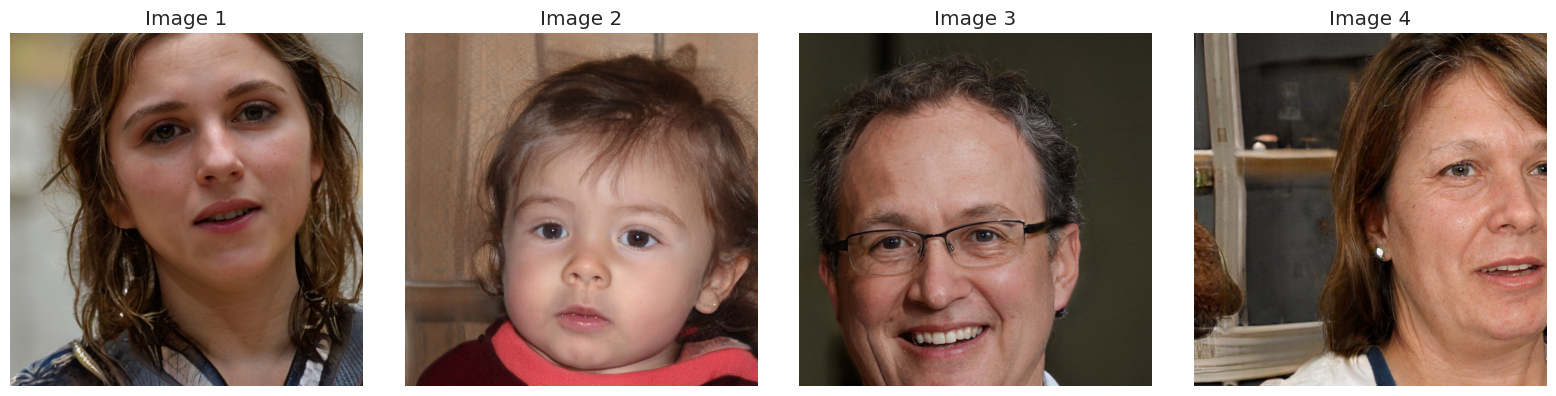

✅ Изображение сохранено как /content/generated_face.png


In [ ]:
import pickle
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# 1. НАСТРОЙКА УСТРОЙСТВА
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {device}')
print(f'CUDA доступна: {torch.cuda.is_available()}')

# 2. ЗАГРУЗКА МОДЕЛИ
network_pkl = '/content/stylegan3-t-ffhqu-1024x1024.pkl'
print(f'Загрузка модели из: {network_pkl}')

with open(network_pkl, 'rb') as f:
    # Загружаем на CPU, затем переносим на доступное устройство
    data = pickle.load(f)
    G = data['G_ema'].to(device)

print(f'✅ Модель загружена на {device}')
print(f'Тип модели: {type(G)}')

# 3. ГЕНЕРАЦИЯ ИЗОБРАЖЕНИЙ
def generate_image(G, device, seed=None, truncation_psi=0.7):
    """Генерирует одно изображение"""
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)

    # Генерация латентного вектора (z) и стилей (w)
    z = torch.randn(1, G.z_dim, device=device)

    # Опционально: метки класса (если есть)
    c = None

    # Генерация изображения
    with torch.no_grad():
        img = G(z, c, truncation_psi=truncation_psi)

    return img

# 4. ВИЗУАЛИЗАЦИЯ
def show_generated_images(G, device, num_images=4, seed=42):
    """Генерирует и показывает несколько изображений"""
    torch.manual_seed(seed)

    fig, axes = plt.subplots(1, num_images, figsize=(4*num_images, 4))
    if num_images == 1:
        axes = [axes]

    for i in range(num_images):
        with torch.no_grad():
            z = torch.randn(1, G.z_dim, device=device)
            img = G(z, None, truncation_psi=0.7)

        # Преобразование тензора в изображение
        img = (img + 1) / 2  # Денормализация из [-1,1] в [0,1]
        img = img[0].permute(1, 2, 0).cpu().numpy()
        img = np.clip(img, 0, 1)

        axes[i].imshow(img)
        axes[i].axis('off')
        axes[i].set_title(f'Image {i+1}')

    plt.tight_layout()
    plt.show()

# 5. ПРИМЕР ИСПОЛЬЗОВАНИЯ
print("\nГенерация изображений...")
show_generated_images(G, device, num_images=4, seed=42)

# Сохранение одного изображения
img = generate_image(G, device, seed=123)
img_np = ((img[0].permute(1, 2, 0).cpu().numpy() + 1) / 2 * 255).astype(np.uint8)
Image.fromarray(img_np).save('/content/generated_face.png')
print("✅ Изображение сохранено как /content/generated_face.png")

**StyleCLIP**

StyleCLIP: Text-Driven Manipulation of StyleGAN Imagery https://arxiv.org/pdf/2103.17249

https://github.com/orpatashnik/StyleCLIP

In [ ]:
# Клонируем репозиторий StyleCLIP
!git clone https://github.com/orpatashnik/StyleCLIP.git
%cd StyleCLIP/global_directions

# Установка зависимостей (TensorFlow 1.x)
!pip install tensorflow-gpu==1.15

# Импорты
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
import pickle
import dnnlib.tflib as tflib

print("TensorFlow version:", tf.__version__)

In [ ]:
# Скачиваем модель
!gdown https://drive.google.com/uc?id=1EM87UquaoQmk17Q8d5kYIAHqu0dkYqdT -O stylegan2-ffhq-config-f.pkl

# Инициализация TensorFlow
tflib.init_tf()

# Загрузка модели
with open('stylegan2-ffhq-config-f.pkl', 'rb') as f:
    G, D, Gs = pickle.load(f)

print("Модель загружена")

In [ ]:
def generate_image(G, w, truncation_psi=0.7):
    """Генерирует изображение из латентного кода w."""
    w = w.astype(np.float32)
    out = Gs.run(w, None, truncation_psi=truncation_psi, randomize_noise=False)
    out = (out + 1) * 127.5
    return np.clip(out, 0, 255).astype(np.uint8)

def show_image(img, title=None):
    """Отображает изображение."""
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    if title:
        plt.title(title)
    plt.show()

def save_image(img, path):
    """Сохраняет изображение."""
    Image.fromarray(img).save(path)
    print(f"Сохранено: {path}")

In [ ]:
import os
import zipfile
import glob

# Путь к распакованным файлам
extract_folder = '/content'
faces_folder = os.path.join(extract_folder, 'faces_dataset_small')


In [ ]:
# Установка e4e (ещё не установлен)
!git clone https://github.com/omertov/encoder4editing.git
%cd encoder4editing

!pip install -r requirements.txt

# Скачивание предобученного энкодера
!gdown https://drive.google.com/uc?id=1cUv_reLE6k3604or78EranS7XzuVMWeO -O e4e_ffhq_encode.pt

# Функция для массовой инверсии
def invert_images_batch(image_folder, output_file='w_plus_my_faces.npy', max_images=100):
    """
    Инвертирует все изображения из папки в латентные коды w+.

    Args:
        image_folder: папка с изображениями
        output_file: файл для сохранения w+ кодов
        max_images: максимальное количество изображений
    """
    import torch
    import numpy as np
    from PIL import Image
    import torchvision.transforms as transforms
    from models.psp import pSp
    from tqdm.notebook import tqdm

    # Загрузка энкодера
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    encoder = pSp(ckpt_path='e4e_ffhq_encode.pt').to(device)
    encoder.eval()

    # Поиск изображений
    images = glob.glob(os.path.join(image_folder, '*.png'))[:max_images]
    print(f"Найдено {len(images)} изображений для инверсии")

    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])

    w_plus_list = []

    for img_path in tqdm(images):
        img = Image.open(img_path).convert('RGB')
        img_tensor = transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            w_plus = encoder(img_tensor)  # (1, 18, 512)
        w_plus_list.append(w_plus.cpu().numpy()[0])

    # Сохранение
    w_plus_array = np.array(w_plus_list)
    np.save(output_file, w_plus_array)
    print(f"Сохранено {len(w_plus_list)} w+ кодов в {output_file}")
    return w_plus_array

# Запуск инверсии (может занять 10-30 минут на 100 изображений)
%cd /content
w_plus_my_faces = invert_images_batch(faces_folder, max_images=50)

In [ ]:
# Переход в папку StyleCLIP
%cd /content/StyleCLIP/global_directions

# Загрузка модели StyleGAN2
import pickle
import dnnlib.tflib as tflib
import numpy as np
import matplotlib.pyplot as plt

tflib.init_tf()
with open('stylegan2-ffhq-config-f.pkl', 'rb') as f:
    G, D, Gs = pickle.load(f)

def generate_from_w(w, truncation_psi=0.7):
    """Генерирует изображение из w (numpy, shape (18, 512))."""
    w = w.astype(np.float32)
    if w.ndim == 2:
        w = w[np.newaxis, ...]
    out = Gs.run(w, None, truncation_psi=truncation_psi, randomize_noise=False)
    out = (out + 1) * 127.5
    return np.clip(out, 0, 255).astype(np.uint8)[0]

# Загрузка инвертированных кодов
w_my_faces = np.load('/content/w_plus_my_faces.npy')
print(f"Загружено {w_my_faces.shape[0]} лиц, форма: {w_my_faces.shape[1:]}")

# Берём первое лицо
w_example = w_my_faces[0]
img = generate_from_w(w_example)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
plt.title('My Face (Inverted)')
plt.show()

In [ ]:
def compare_original_vs_reconstructed(image_path, w):
    """Сравнивает оригинальное и реконструированное изображение."""
    original = Image.open(image_path).resize((256, 256))
    reconstructed = generate_from_w(w)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(original)
    axes[0].set_title('Original')
    axes[0].axis('off')

    axes[1].imshow(reconstructed)
    axes[1].set_title('Reconstructed')
    axes[1].axis('off')
    plt.show()

# Сравнение для первого изображения
first_image = glob.glob(os.path.join(faces_folder, '*.png'))[0]
compare_original_vs_reconstructed(first_image, w_my_faces[0])

 **DDGAN**

 Denoising Diffusion GANs  https://arxiv.org/pdf/2112.07804

 https://github.com/openai/guided-diffusion

In [ ]:
# ============================================================
# 1. УСТАНОВКА И ЗАГРУЗКА РЕПОЗИТОРИЯ
# ============================================================
!git clone https://github.com/NVlabs/denoising-diffusion-gan.git
%cd denoising-diffusion-gan

# Установка зависимостей
!pip install -r requirements.txt

import os
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import glob

print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")

# ============================================================
# 2. ПОДГОТОВКА ВАШЕГО ДАТАСЕТА
# ============================================================
# Путь к вашему датасету
DATASET_PATH = '/content/faces_dataset_small'

# Поиск изображений
image_paths = glob.glob(os.path.join(DATASET_PATH, '*.png'))
if not image_paths:
    image_paths = glob.glob(os.path.join(DATASET_PATH, '*.jpg'))
    image_paths += glob.glob(os.path.join(DATASET_PATH, '*.jpeg'))

print(f"Найдено {len(image_paths)} изображений")

# Создаём класс датасета
class FaceDataset(Dataset):
    def __init__(self, image_paths, image_size=64):
        self.image_paths = image_paths
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # [-1, 1]
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        return self.transform(img)

# Параметры
IMAGE_SIZE = 64  # DDGAN хорошо работает с 64x64
BATCH_SIZE = 64
NUM_WORKERS = 4

# Создаём датасет и даталоадер
dataset = FaceDataset(image_paths, image_size=IMAGE_SIZE)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=NUM_WORKERS, pin_memory=True)

print(f"Размер датасета: {len(dataset)}")
print(f"Количество батчей: {len(dataloader)}")

# Визуализация образцов
def show_samples():
    images, _ = next(iter(dataloader))
    images = (images + 1) / 2.0
    grid = torchvision.utils.make_grid(images[:16], nrow=4, padding=2)
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis('off')
    plt.title('Sample training images')
    plt.show()

show_samples()

# ============================================================
# 3. ЗАГРУЗКА ПРЕДОБУЧЕННОЙ МОДЕЛИ (CIFAR-10)
# ============================================================
# Скачиваем предобученную модель DDGAN (4 шага)
!wget https://nvlabs-fi-cdn.nvidia.com/denoising-diffusion-gan/pretrained/ddgan_cifar10_4steps.pth -O ddgan_pretrained.pth

# Импорт модулей DDGAN
import sys
sys.path.append('/content/denoising-diffusion-gan')

from models import ddgan
from utils import yaml_utils

# Загрузка конфигурации
config_path = 'configs/cifar10_4steps.yaml'
config = yaml_utils.load_config_file(config_path)

# Адаптация конфигурации под ваш датасет
config['data']['image_size'] = IMAGE_SIZE
config['data']['channels'] = 3
config['training']['batch_size'] = BATCH_SIZE
config['training']['n_epochs'] = 200

# Инициализация модели
model = ddgan.DDGAN(config)
model = model.cuda()

# Загрузка предобученных весов (кроме последнего слоя)
pretrained = torch.load('ddgan_pretrained.pth', map_location='cpu')
model_dict = model.state_dict()
pretrained_dict = {k: v for k, v in pretrained.items()
                   if k in model_dict and v.shape == model_dict[k].shape}
model_dict.update(pretrained_dict)
model.load_state_dict(model_dict)
print(f"Загружено {len(pretrained_dict)} слоёв из предобученной модели")

# ============================================================
# 4. НАСТРОЙКА ОПТИМИЗАТОРОВ И ОБУЧЕНИЯ
# ============================================================
import torch.optim as optim

# Параметры обучения
LEARNING_RATE = 2e-4
NUM_EPOCHS = 100
STEPS_PER_EPOCH = len(dataloader)

# Оптимизаторы
optimizer_G = optim.Adam(model.generator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.9))
optimizer_D = optim.Adam(model.discriminator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.9))

# Сброс счётчика шагов (для дообучения)
model.step = 0

# Для отслеживания лоссов
losses_G = []
losses_D = []

# ============================================================
# 5. ЦИКЛ ДООБУЧЕНИЯ
# ============================================================
print("\n=== НАЧАЛО ДООБУЧЕНИЯ ===")

for epoch in range(NUM_EPOCHS):
    epoch_loss_G = 0.0
    epoch_loss_D = 0.0

    for batch_idx, real_imgs in enumerate(dataloader):
        real_imgs = real_imgs.cuda()

        # --- Обучение дискриминатора ---
        optimizer_D.zero_grad()

        # Случайный шаг времени t
        t = torch.randint(0, model.num_timesteps, (real_imgs.size(0),), device='cuda')

        # Добавление шума к реальным изображениям
        noise = torch.randn_like(real_imgs)
        x_t = model.q_sample(real_imgs, t, noise)

        # Генерация фейковых x_{t-1}
        with torch.no_grad():
            x_t_minus_1_fake = model.sample_step(x_t, t)

        # Пары для дискриминатора
        real_pairs = torch.cat([x_t, real_imgs], dim=1)  # (x_t, real x_{t-1})
        fake_pairs = torch.cat([x_t, x_t_minus_1_fake], dim=1)  # (x_t, fake x_{t-1})

        # Потеря дискриминатора
        d_real = model.discriminator(real_pairs, t)
        d_fake = model.discriminator(fake_pairs, t)

        loss_D = (torch.nn.functional.softplus(-d_real) + torch.nn.functional.softplus(d_fake)).mean()

        loss_D.backward()
        optimizer_D.step()

        # --- Обучение генератора ---
        optimizer_G.zero_grad()

        # Повторяем шаг для генератора
        t = torch.randint(0, model.num_timesteps, (real_imgs.size(0),), device='cuda')
        noise = torch.randn_like(real_imgs)
        x_t = model.q_sample(real_imgs, t, noise)

        # Генерация x_{t-1} через генератор
        z = torch.randn_like(real_imgs)
        x_t_minus_1_fake = model.generator(x_t, t, z)

        fake_pairs = torch.cat([x_t, x_t_minus_1_fake], dim=1)
        d_fake = model.discriminator(fake_pairs, t)

        loss_G = torch.nn.functional.softplus(-d_fake).mean()

        loss_G.backward()
        optimizer_G.step()

        epoch_loss_G += loss_G.item()
        epoch_loss_D += loss_D.item()

        if batch_idx % 100 == 0:
            print(f"Epoch {epoch+1:3d} | Step {batch_idx:4d} | D loss: {loss_D.item():.4f} | G loss: {loss_G.item():.4f}")

    # Усреднение лоссов за эпоху
    avg_loss_G = epoch_loss_G / len(dataloader)
    avg_loss_D = epoch_loss_D / len(dataloader)
    losses_G.append(avg_loss_G)
    losses_D.append(avg_loss_D)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | D loss: {avg_loss_D:.4f} | G loss: {avg_loss_G:.4f}")

    # Сохранение модели каждые 20 эпох
    if (epoch + 1) % 20 == 0:
        torch.save(model.state_dict(), f'ddgan_finetuned_epoch_{epoch+1}.pth')
        print(f"Модель сохранена: ddgan_finetuned_epoch_{epoch+1}.pth")

print("=== ДООБУЧЕНИЕ ЗАВЕРШЕНО ===")

# ============================================================
# 6. ГЕНЕРАЦИЯ ИЗОБРАЖЕНИЙ ПОСЛЕ ДООБУЧЕНИЯ
# ============================================================
def generate_images(model, num_images=16, steps=4):
    """Генерирует изображения."""
    model.eval()
    with torch.no_grad():
        # Начинаем с шума
        x = torch.randn(num_images, 3, IMAGE_SIZE, IMAGE_SIZE, device='cuda')
        for t in reversed(range(steps)):
            x = model.sample_step(x, torch.full((num_images,), t, device='cuda'))

    images = (x + 1) / 2.0
    return images.clamp(0, 1)

def show_grid(images, nrow=4, figsize=(8, 8)):
    grid = torchvision.utils.make_grid(images, nrow=nrow, padding=2)
    plt.figure(figsize=figsize)
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis('off')
    plt.show()

# Генерация
generated = generate_images(model, num_images=16, steps=4)
show_grid(generated, nrow=4)

# Сохранение
torchvision.utils.save_image(generated, 'ddgan_generated_faces.png', nrow=4)
print("Изображения сохранены в ddgan_generated_faces.png")

# ============================================================
# 7. ВИЗУАЛИЗАЦИЯ ЛОССОВ
# ============================================================
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(losses_G, label='Generator Loss')
plt.plot(losses_D, label='Discriminator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('DDGAN Training Losses')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(losses_D, label='Discriminator Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Discriminator Loss (convergence)')
plt.grid(True)
plt.tight_layout()
plt.savefig('ddgan_losses.png')
plt.show()

# ============================================================
# 8. СРАВНЕНИЕ ДО И ПОСЛЕ ДООБУЧЕНИЯ
# ============================================================
def visualize_progression(model, epoch):
    """Визуализирует прогресс генерации."""
    model.eval()
    with torch.no_grad():
        x = torch.randn(16, 3, IMAGE_SIZE, IMAGE_SIZE, device='cuda')
        steps = [1, 2, 3, 4]
        images = []
        for step in steps:
            x_tmp = x.clone()
            for t in reversed(range(step)):
                x_tmp = model.sample_step(x_tmp, torch.full((16,), t, device='cuda'))
            images.append((x_tmp + 1) / 2.0)

        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        for i, (img, step) in enumerate(zip(images, steps)):
            grid = torchvision.utils.make_grid(img, nrow=4, padding=2)
            axes[i].imshow(grid.permute(1, 2, 0).cpu())
            axes[i].set_title(f'{step} step(s)')
            axes[i].axis('off')
        plt.suptitle(f'Generation after {NUM_EPOCHS} epochs')
        plt.tight_layout()
        plt.show()

visualize_progression(model, NUM_EPOCHS)

##  Постройте графики лосса для генератора и дискриминатора. Что вы можете сказать про эти графики?

Граффики лоссов GAN для  генератора и дискриминатора графики лоссов взаимосвязаны, динамической связью в рамках минимаксной игры.


**GAN**

In [ ]:
epochs = 50
lr = 0.0001

losses_g, losses_d = fit(model, criterion, epochs, lr)

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch [1/50] Loss_D: 0.1281 Loss_G: 5.5252


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch [2/50] Loss_D: 0.0416 Loss_G: 10.2716


  0%|          | 0/50 [00:00<?, ?it/s]

...

Epoch [48/50] Loss_D: 0.0030 Loss_G: 10.4111


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch [49/50] Loss_D: 0.6663 Loss_G: 5.6424


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch [50/50] Loss_D: 0.0249 Loss_G: 5.1958


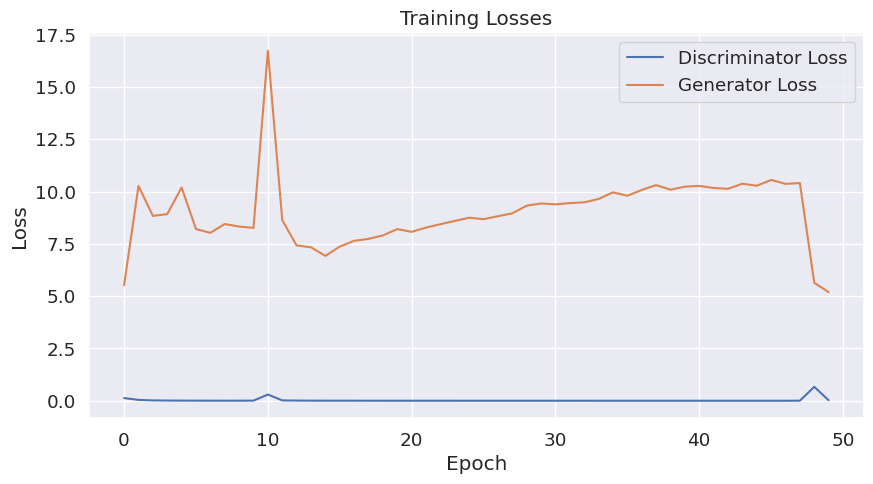

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(losses_d, label='Discriminator Loss')
plt.plot(losses_g, label='Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Losses')
plt.show()

**WGAN-GP**

In [ ]:
for epoch in range(epochs):
    loss_c_epoch = 0.0
    loss_g_epoch = 0.0
    num_batches = 0

    for real_imgs, _ in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)

        # --- 1. Обучаем критика (n_critic раз) ---
        for _ in range(n_critic):
            optimizer_C.zero_grad()

            # Реальные изображения
            real_validity = critic(real_imgs)

            # Фейковые изображения
            z = torch.randn(batch_size, latent_size, 1, 1, device=device)
            fake_imgs = generator(z)
            fake_validity = critic(fake_imgs.detach())

            # Wasserstein loss (критик максимизирует разницу)
            loss_c = -real_validity.mean() + fake_validity.mean()

            # Градиентный штраф
            gp = compute_gradient_penalty(critic, real_imgs, fake_imgs)

            # Полная потеря критика
            loss_c_total = loss_c + lambda_gp * gp
            loss_c_total.backward()
            optimizer_C.step()

        # --- 2. Обучаем генератор (один раз) ---
        optimizer_G.zero_grad()

        z = torch.randn(batch_size, latent_size, 1, 1, device=device)
        fake_imgs = generator(z)
        fake_validity = critic(fake_imgs)

        # Генератор хочет, чтобы критик давал большие значения (уменьшаем отрицательное)
        loss_g = -fake_validity.mean()

        loss_g.backward()
        optimizer_G.step()

        # Сохраняем лоссы
        loss_c_epoch += loss_c_total.item()
        loss_g_epoch += loss_g.item()
        num_batches += 1

    # Усредняем за эпоху
    avg_loss_c = loss_c_epoch / num_batches
    avg_loss_g = loss_g_epoch / num_batches
    losses_c.append(avg_loss_c)
    losses_g.append(avg_loss_g)

    print(f"Epoch [{epoch+1}/{epochs}] Loss_C: {avg_loss_c:.4f} Loss_G: {avg_loss_g:.4f}")


Epoch 1/50:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch [1/50] Loss_C: -150.5803 Loss_G: 74.2415


Epoch 2/50:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch [2/50] Loss_C: -396.7505 Loss_G: 198.0095


Epoch 3/50:   0%|          | 0/50 [00:00<?, ?it/s]

...

Epoch [48/50] Loss_C: -47.4532 Loss_G: 4426.9206


Epoch 49/50:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch [49/50] Loss_C: -36.4687 Loss_G: 4407.4964


Epoch 50/50:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch [50/50] Loss_C: -43.2615 Loss_G: 4386.9834


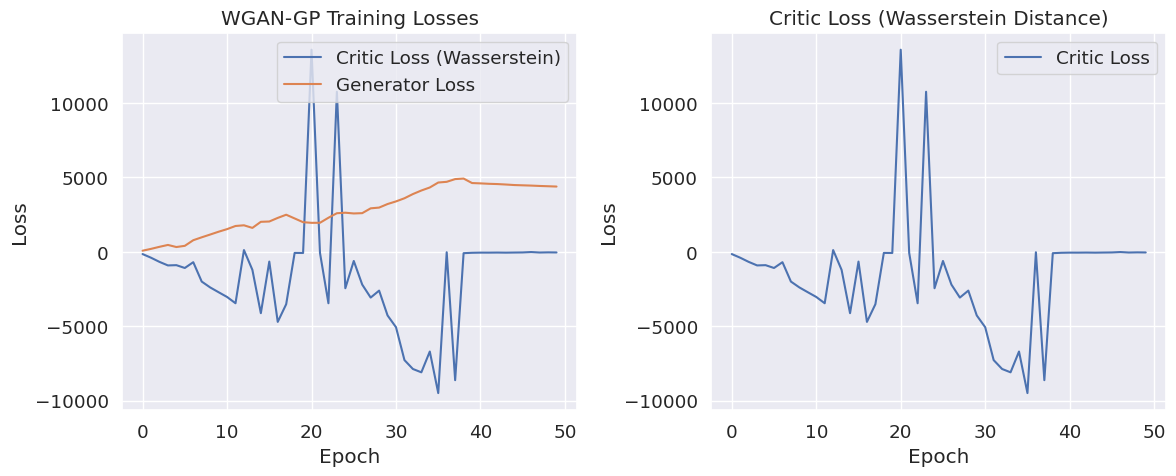

In [ ]:

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(losses_c, label='Critic Loss (Wasserstein)')
plt.plot(losses_g, label='Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('WGAN-GP Training Losses')

plt.subplot(1, 2, 2)
plt.plot(losses_c, label='Critic Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Critic Loss (Wasserstein Distance)')
plt.tight_layout()
plt.show()

**StyleGAN‑2**

In [ ]:
print("\n   StyleGAN-2...")
print("="*60)

losses_g, losses_d = fit(
    model=model,
    criterion=criterion,
    epochs=5,
    lr=lr,
    device=device,
    dataloader=dataloader,
    latent_size=latent_size,
    d_reg_interval=16,
    g_reg_interval=4,
    r1_gamma=10
)


   StyleGAN-2...
Начало обучения на cuda


Epoch 1/5:   0%|          | 0/392 [00:00<?, ?it/s]

Step 1: D_loss=5.0000, G_loss=0.0000


KeyboardInterrupt: 

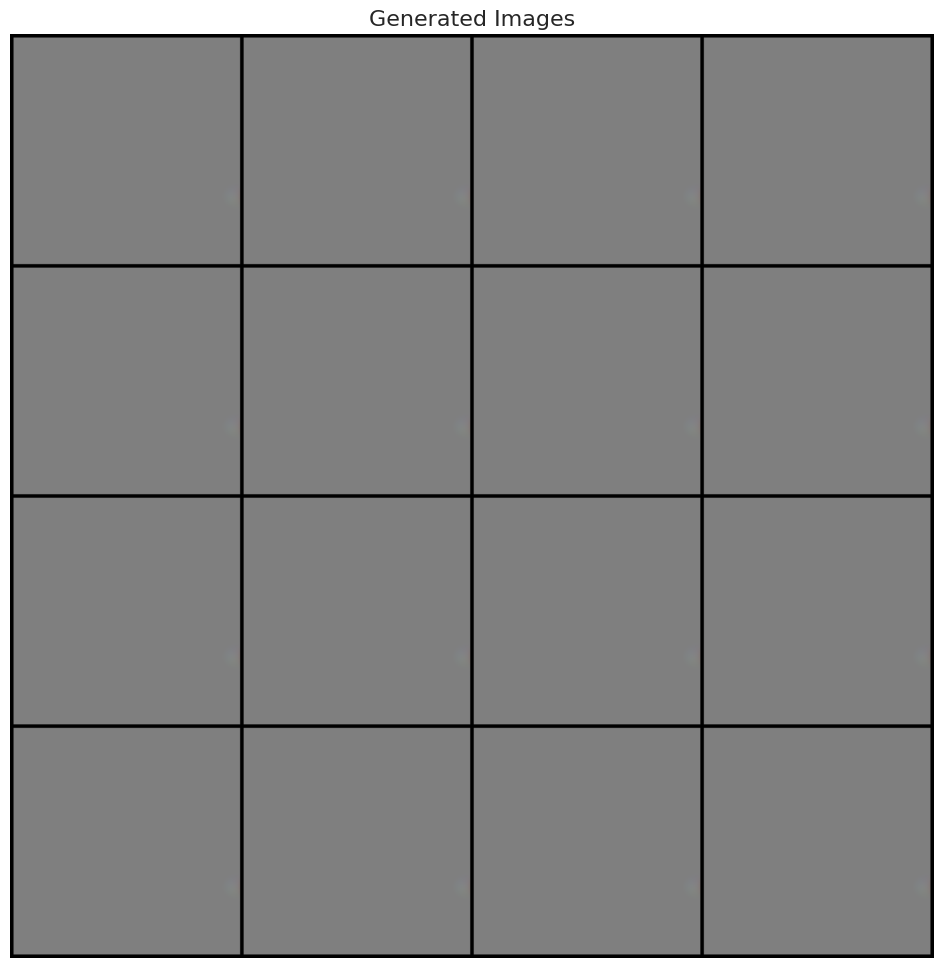

  Модель сохранена в 'my_generator.pth'


In [ ]:


generator.eval()
with torch.no_grad():
    z_test = torch.randn(16, latent_size, device=device)
    fake_test = generator(z_test, truncation_psi=0.7)
    fake_test = (fake_test + 1) / 2
    fake_test = torch.clamp(fake_test, 0, 1)

    # Отображаем
    grid = make_grid(fake_test, nrow=4, padding=2)
    plt.figure(figsize=(12, 12))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.axis('off')
    plt.title("Generated Images", fontsize=16)
    plt.show()

    # Сохраняем модель
    torch.save(generator.state_dict(), 'my_generator.pth')
    print("  Модель сохранена в 'my_generator.pth'")


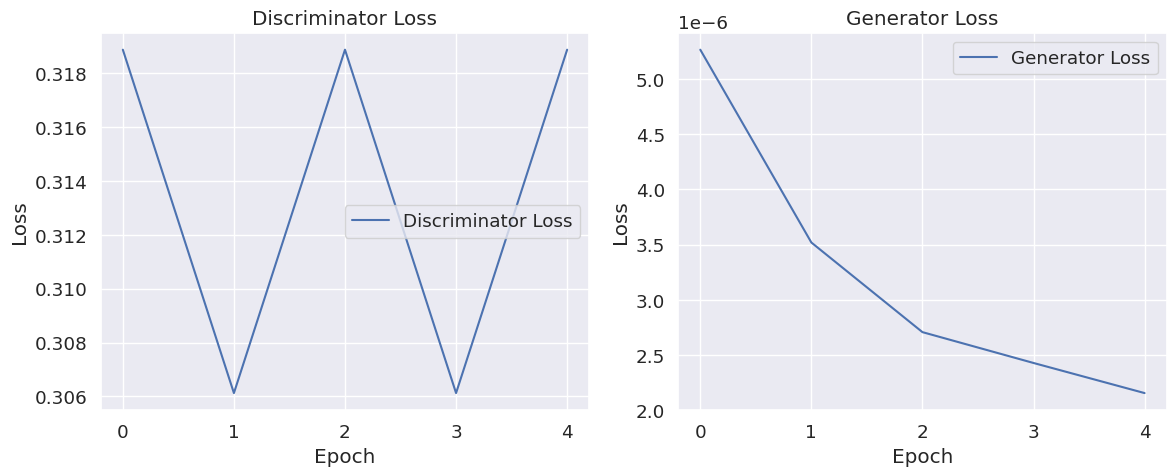

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(losses_d, label='Discriminator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Discriminator Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(losses_g, label='Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Generator Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**StyleGAN‑2‑ADA**

In [ ]:
data_iter = iter(dataloader)
batch_idx = 0
total_batches = total_kimg * 1000 // batch_size  # total_kimg в тысячах

for step in range(total_batches):
    # Загрузка батча
    try:
        real_imgs, _ = next(data_iter)
    except StopIteration:
        data_iter = iter(dataloader)
        real_imgs, _ = next(data_iter)

    real_imgs = real_imgs.to(device)
    batch = real_imgs.size(0)

    # --- Обучение дискриминатора ---
    z = random_noise(batch, 512).to(device)
    with torch.no_grad():
        fake_imgs = G(z)

    # Аугментации для дискриминатора
    real_aug = misc.apply_augment(real_imgs, augment_p)  # из stylegan2_ada_pytorch
    fake_aug = misc.apply_augment(fake_imgs, augment_p)

    # Потеря дискриминатора (логистическая + R1)
    d_real = D(real_aug)
    d_fake = D(fake_aug)

    loss_D_real = torch.nn.functional.softplus(-d_real).mean()
    loss_D_fake = torch.nn.functional.softplus(d_fake).mean()
    loss_D = loss_D_real + loss_D_fake

    # R1 регуляризация (каждые 16 шагов)
    if step % 16 == 0:
        real_imgs.requires_grad_(True)
        d_real_reg = D(real_imgs)
        grad = torch.autograd.grad(outputs=d_real_reg.sum(), inputs=real_imgs, create_graph=True)[0]
        r1_loss = (grad.view(batch, -1).norm(dim=1)**2).mean()
        loss_D = loss_D + 10.0 * r1_loss
        real_imgs.requires_grad_(False)

    optimizer_D.zero_grad()
    loss_D.backward()
    optimizer_D.step()

    # --- Обучение генератора ---
    z = random_noise(batch, 512).to(device)
    fake_imgs = G(z)
    fake_aug = misc.apply_augment(fake_imgs, augment_p)
    d_fake = D(fake_aug)

    loss_G = torch.nn.functional.softplus(-d_fake).mean()

    optimizer_G.zero_grad()
    loss_G.backward()
    optimizer_G.step()

    # --- Обновление скользящего среднего генератора ---
    misc.update_ema(G_ema, G, decay=0.5**(batch / (10 * 1000)))  # эмпирически

    # --- Адаптивное обновление p (ADA) ---
    with torch.no_grad():
        # Эвристика r_t: доля положительных выходов на реальных
        r_t = (D(real_imgs) > 0).float().mean().item()

    if r_t > ada_target:
        augment_p += 0.0005
    else:
        augment_p -= 0.0005
    augment_p = max(augment_p, 0.0)

    # --- Сохранение лоссов ---
    losses_g.append(loss_G.item())
    losses_d.append(loss_D.item())
    steps.append(step)
    p_vals.append(augment_p)

    if step % 100 == 0:
        print(f"Step {step:6d} | D loss: {loss_D.item():.4f} | G loss: {loss_G.item():.4f} | p: {augment_p:.3f}")

In [ ]:
plt.figure(figsize=(12, 5))

# Левый график: оба лосса
plt.subplot(1, 2, 1)
plt.plot(steps, losses_g, label='Generator Loss', alpha=0.7, linewidth=1)
plt.plot(steps, losses_d, label='Discriminator Loss', alpha=0.7, linewidth=1)
plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.legend()
plt.title('StyleGAN-2-ADA Training Losses (G vs D)')
plt.grid(True, alpha=0.3)

# Правый график: только лосс дискриминатора
plt.subplot(1, 2, 2)
plt.plot(steps, losses_d, label='Discriminator Loss', color='orange', linewidth=1)
plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.legend()
plt.title('Discriminator Loss (convergence)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Дополнительный график: адаптивная вероятность аугментаций
plt.figure(figsize=(10, 4))
plt.plot(steps, p_vals, color='green', linewidth=1)
plt.xlabel('Training Step')
plt.ylabel('Augmentation probability p')
plt.title('ADA: Adaptive augmentation strength')
plt.grid(True, alpha=0.3)
plt.show()

## Часть 3. Генерация изображений

Теперь давайте оценим качество получившихся изображений. Напишите функцию, которая выводит изображения, сгенерированные нашим генератором

**GAN**

In [ ]:
n_images = 4

fixed_latent = torch.randn(n_images, latent_size, 1, 1, device=device)
fake_images = model["generator"](fixed_latent)

In [ ]:
def show_images(generated, nrow=4, figsize=(8, 8)):
    """
    Визуализирует сгенерированные изображения.

    Args:
        generated: тензор с изображениями (B, C, H, W) в диапазоне [-1, 1]
        nrow: количество изображений в строке (для make_grid)
        figsize: размер фигуры (ширина, высота)
    """
    # Переводим изображения в CPU и отключаем вычисление градиентов
    generated = generated.detach().cpu()

    # Денормализация: из [-1, 1] в [0, 1]
    def denorm(img_tensor):
        return (img_tensor + 1) / 2.0

    generated_denorm = denorm(generated)

    # Создаём сетку изображений
    grid = make_grid(generated_denorm, nrow=nrow, padding=2)

    # Преобразуем для отображения в matplotlib
    grid_np = grid.permute(1, 2, 0).numpy()

    # Визуализация
    plt.figure(figsize=figsize)
    plt.imshow(grid_np)
    plt.axis('off')
    plt.title("Generated Images")
    plt.show()

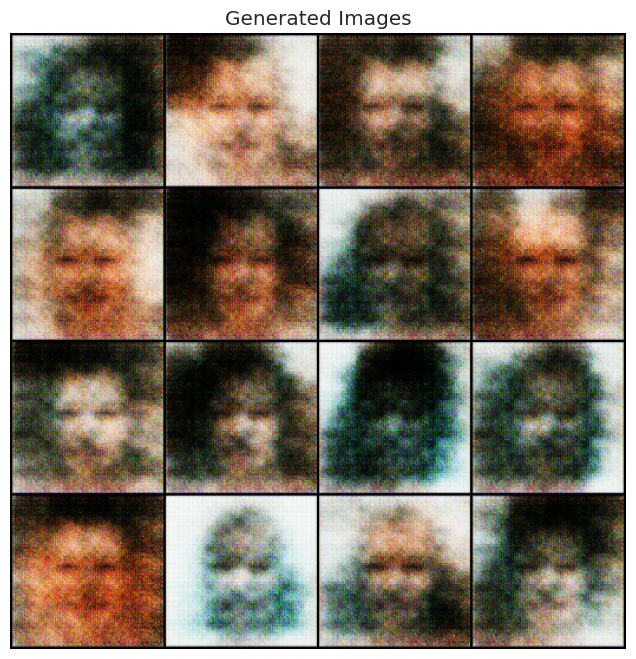

In [ ]:
with torch.no_grad():
    z = torch.randn(16, latent_size, 1, 1, device=device)
    generated = generator(z)

show_images(generated=generated, nrow=4, figsize=(8, 8))

**WGAN-GP**

In [ ]:
def denorm(img_tensor):
    return (img_tensor + 1) / 2.0

def show_generated_images(generator, n_images=16, nrow=4):
    generator.eval()
    with torch.no_grad():
        z = torch.randn(n_images, latent_size, 1, 1, device=device)
        fake_imgs = generator(z).cpu()

    fake_imgs = denorm(fake_imgs)

    from torchvision.utils import make_grid
    grid = make_grid(fake_imgs, nrow=nrow, padding=2)

    plt.figure(figsize=(12, 12))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis('off')
    plt.title('Generated Images (WGAN-GP)')
    plt.show()



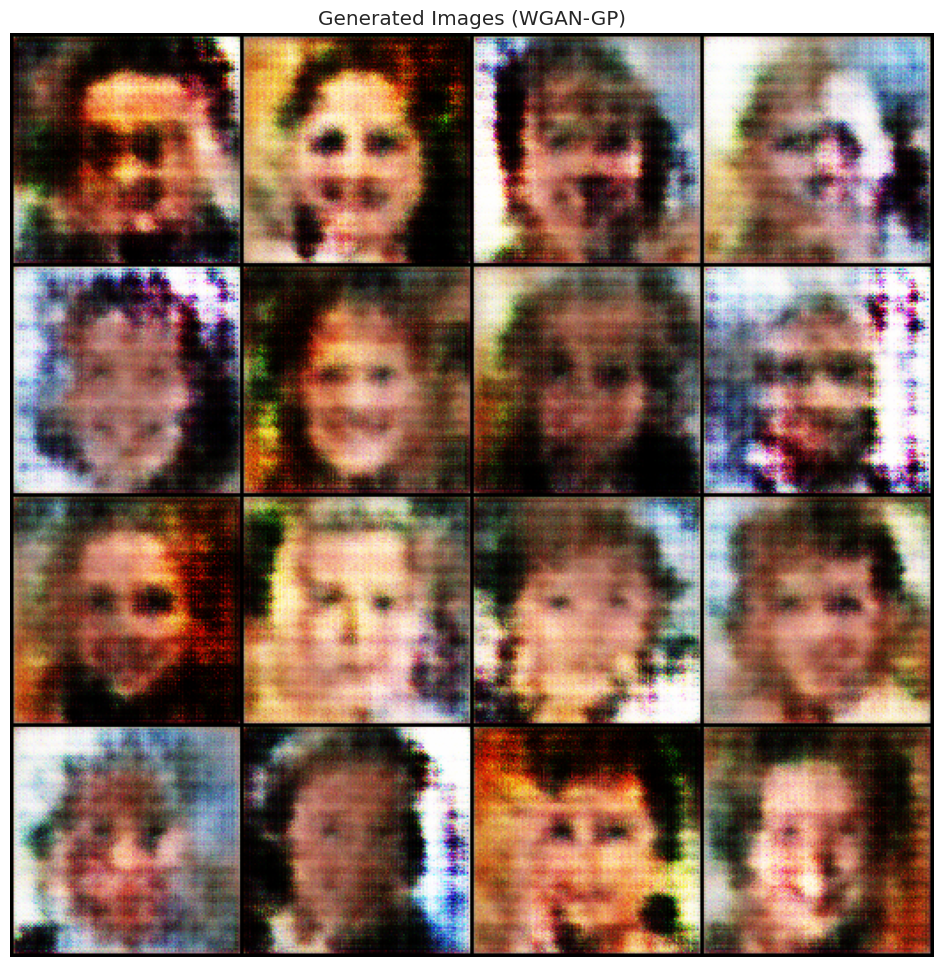

In [ ]:
show_generated_images(generator, n_images=16, nrow=4)

**StyleGAN‑2**

In [ ]:
def generate_images(generator, num_images=16, latent_size=512, device='cuda', truncation_psi=0.7):
    """
    Генерация изображений после обучения

    Args:
        generator: обученная модель генератора
        num_images: количество изображений для генерации
        latent_size: размер латентного вектора
        device: устройство (cuda/cpu)
        truncation_psi: параметр усечения (качество vs разнообразие)
    """
    generator.eval()  # Переводим в режим оценки
    generator.to(device)

    with torch.no_grad():  # Отключаем вычисление градиентов
        # Генерируем случайные латентные векторы
        z = torch.randn(num_images, latent_size, device=device)

        # Генерируем изображения
        fake_images = generator(z, truncation_psi=truncation_psi)

        # Нормализуем из [-1, 1] в [0, 1] для отображения
        fake_images = (fake_images + 1) / 2
        fake_images = torch.clamp(fake_images, 0, 1)

    return fake_images.cpu()

# Использование:
generated_imgs = generate_images(generator, num_images=16, device=device)

**StyleGAN‑2‑ADA**

In [ ]:
from stylegan2_ada_pytorch import misc
from stylegan2_ada_pytorch.torch_utils import random_noise

# Загрузка последней модели
snapshot = misc.load_pkl(os.path.join(results_dir, 'network-snapshot-latest.pkl'))
G = snapshot['G_ema'].cuda()  # генератор со скользящим средним

# Генерация
z = random_noise(16, 512)  # 16 изображений, latent_size=512
with torch.no_grad():
    fake_images = G(z, None)  # (16, 3, 128, 128) в [-1, 1]

# Визуализация
def denorm(img): return (img + 1) / 2.0
grid = torchvision.utils.make_grid(denorm(fake_images), nrow=4)
plt.imshow(grid.permute(1,2,0).cpu())
plt.axis('off')
plt.show()

Как вам качество получившихся изображений?

## Часть 4. Leave-one-out-1-NN classifier accuracy (5 баллов)

### 4.1. Подсчет accuracy (3 балл)

Не всегда бывает удобно оценивать качество сгенерированных картинок глазами. В качестве альтернативы вам предлагается реализовать следующий подход:
  * Сгенерировать столько же фейковых изображений, сколько есть настоящих в обучающей выборке. Присвоить фейковым метку класса 0, настоящим – 1.
  * Построить leave-one-out оценку: обучить 1NN Classifier (`sklearn.neighbors.KNeighborsClassifier(n_neighbors=1)`) предсказывать класс на всех объектах, кроме одного, проверить качество (accuracy) на оставшемся объекте. В этом вам поможет `sklearn.model_selection.LeaveOneOut`

In [ ]:
def evaluate_1nn_cv(generator, dataloader, device, latent_size, num_images=500, cv_folds=5):
    """
    Более быстрая версия с k-fold cross-validation.
    """
    generator.eval()

    # Собираем реальные изображения
    real_images_list = []
    for real_batch, _ in dataloader:
        real_images_list.append(real_batch)
    real_images = torch.cat(real_images_list, dim=0)

    if len(real_images) > num_images:
        indices = np.random.choice(len(real_images), num_images, replace=False)
        real_images = real_images[indices]

    n_real = len(real_images)

    # Генерируем фейки
    with torch.no_grad():
        z = torch.randn(n_real, latent_size, 1, 1, device=device)
        fake_images = generator(z).cpu()

    # Flatten
    real_flat = real_images.view(n_real, -1).numpy()
    fake_flat = fake_images.view(n_real, -1).numpy()

    X = np.vstack([real_flat, fake_flat])
    y = np.hstack([np.ones(n_real), np.zeros(n_real)])

    # Stratified k-fold cross-validation
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    knn = KNeighborsClassifier(n_neighbors=1)
    scores = cross_val_score(knn, X, y, cv=cv, scoring='accuracy')

    print(f"1-NN {cv_folds}-fold CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")
    return scores.mean()

# Запуск быстрой версии
accuracy_cv = evaluate_1nn_cv(
    generator=model["generator"],
    dataloader=dataloader,
    device=device,
    latent_size=latent_size,
    num_images=500,
    cv_folds=5
)

1-NN 5-fold CV Accuracy: 1.0000 ± 0.0000


Что вы можете сказать о получившемся результате? Какой accuracy мы хотели бы получить и почему?

1-NN — полезная, но не идеальная метрика. Эта метрика показывает, насколько легко простой классификатор может отличить реальные изображения от сгенерированных  Цель - 0.5

### 4.2. Визуализация распределений (2 балл)

Давайте посмотрим на то, насколько похожи распределения настоящих и фейковых изображений. Для этого воспользуйтесь методом, снижающим размерность (к примеру, TSNE) и изобразите на графике разным цветом точки, соответствующие реальным и сгенерированным изображенияи

**t‑SNE**

PCA: уменьшаем размерность с 49152 до 50...
PCA объясняет дисперсию: 0.93
Запуск t-SNE...


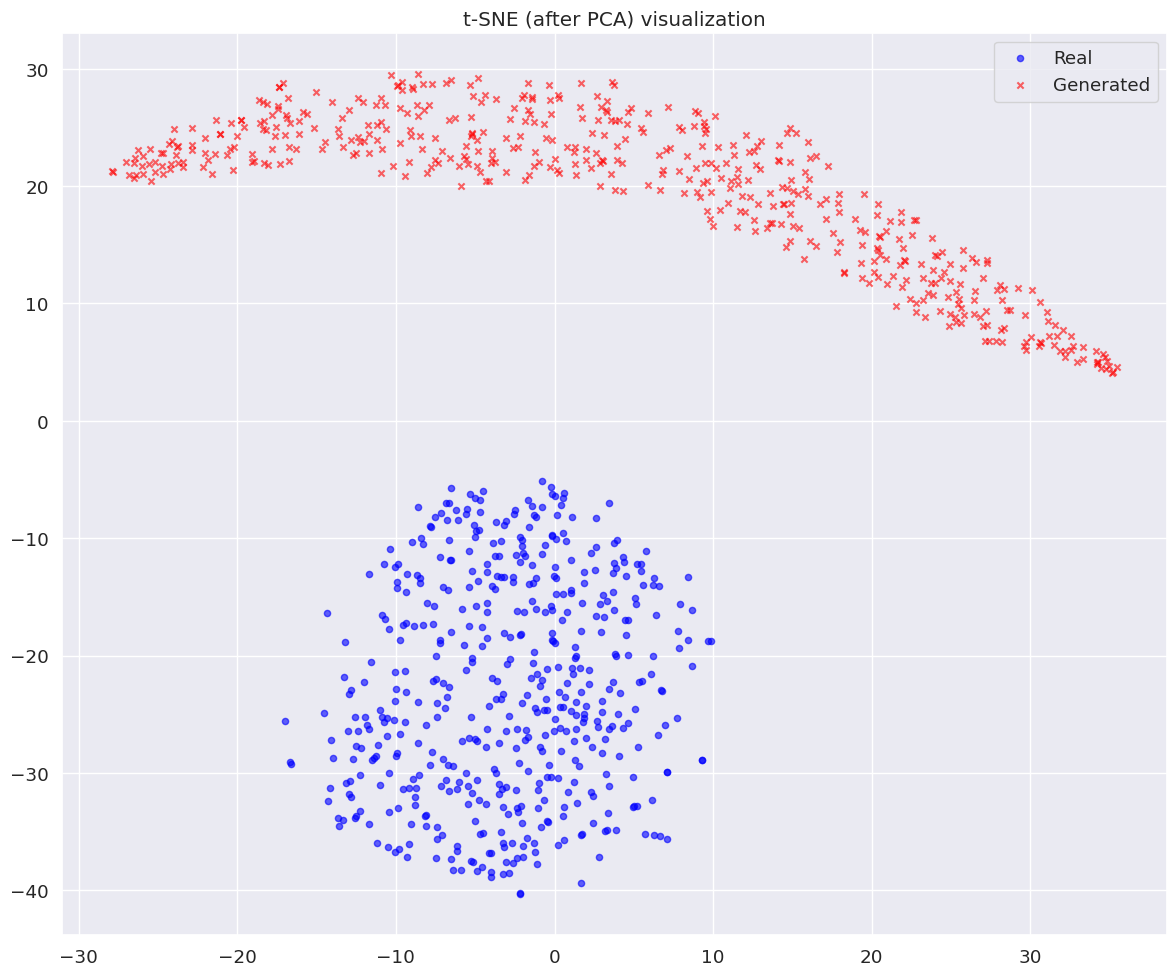

In [ ]:
from sklearn.decomposition import PCA

def visualize_tsne_with_pca(generator, dataloader, device, latent_size, num_images=500, pca_components=50):
    """
    Более быстрая версия: сначала PCA (до 50 компонент), затем t-SNE.
    """
    generator.eval()

    # Сбор данных (как в предыдущей функции)
    real_images_list = []
    for real_batch, _ in dataloader:
        real_images_list.append(real_batch)
        if len(real_images_list) * real_batch.size(0) >= num_images:
            break
    real_images = torch.cat(real_images_list, dim=0)[:num_images]
    n_real = len(real_images)

    with torch.no_grad():
        z = torch.randn(num_images, latent_size, 1, 1, device=device)
        fake_images = generator(z).cpu()

    real_flat = real_images.view(n_real, -1).numpy()
    fake_flat = fake_images.view(num_images, -1).numpy()
    X = np.vstack([real_flat, fake_flat])
    y = np.hstack([np.ones(n_real), np.zeros(num_images)])

    # PCA для уменьшения размерности
    print(f"PCA: уменьшаем размерность с {X.shape[1]} до {pca_components}...")
    pca = PCA(n_components=pca_components, random_state=42)
    X_pca = pca.fit_transform(X)
    print(f"PCA объясняет дисперсию: {pca.explained_variance_ratio_.sum():.2f}")

    # t-SNE на уменьшенных данных
    print("Запуск t-SNE...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='random')
    X_tsne = tsne.fit_transform(X_pca)

    # Визуализация
    plt.figure(figsize=(12, 10))
    plt.scatter(X_tsne[y == 1, 0], X_tsne[y == 1, 1],
                c='blue', marker='o', alpha=0.6, s=20, label='Real')
    plt.scatter(X_tsne[y == 0, 0], X_tsne[y == 0, 1],
                c='red', marker='x', alpha=0.6, s=20, label='Generated')
    plt.legend()
    plt.title('t-SNE (after PCA) visualization')
    plt.tight_layout()
    plt.show()

    return X_tsne, y

# Запуск ускоренной версии
X_tsne, y_labels = visualize_tsne_with_pca(
    generator=model["generator"],
    dataloader=dataloader,
    device=device,
    latent_size=latent_size,
    num_images=500,
    pca_components=50
)

**UMAP**

PCA: уменьшаем размерность с 49152 до 50...
PCA объясняет 93.4% дисперсии
Запуск UMAP...
UMAP(n_jobs=1, random_state=42, verbose=True)
Wed May 27 13:32:30 2026 Construct fuzzy simplicial set


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Wed May 27 13:32:30 2026 Finding Nearest Neighbors
Wed May 27 13:32:31 2026 Finished Nearest Neighbor Search
Wed May 27 13:32:31 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Wed May 27 13:32:33 2026 Finished embedding


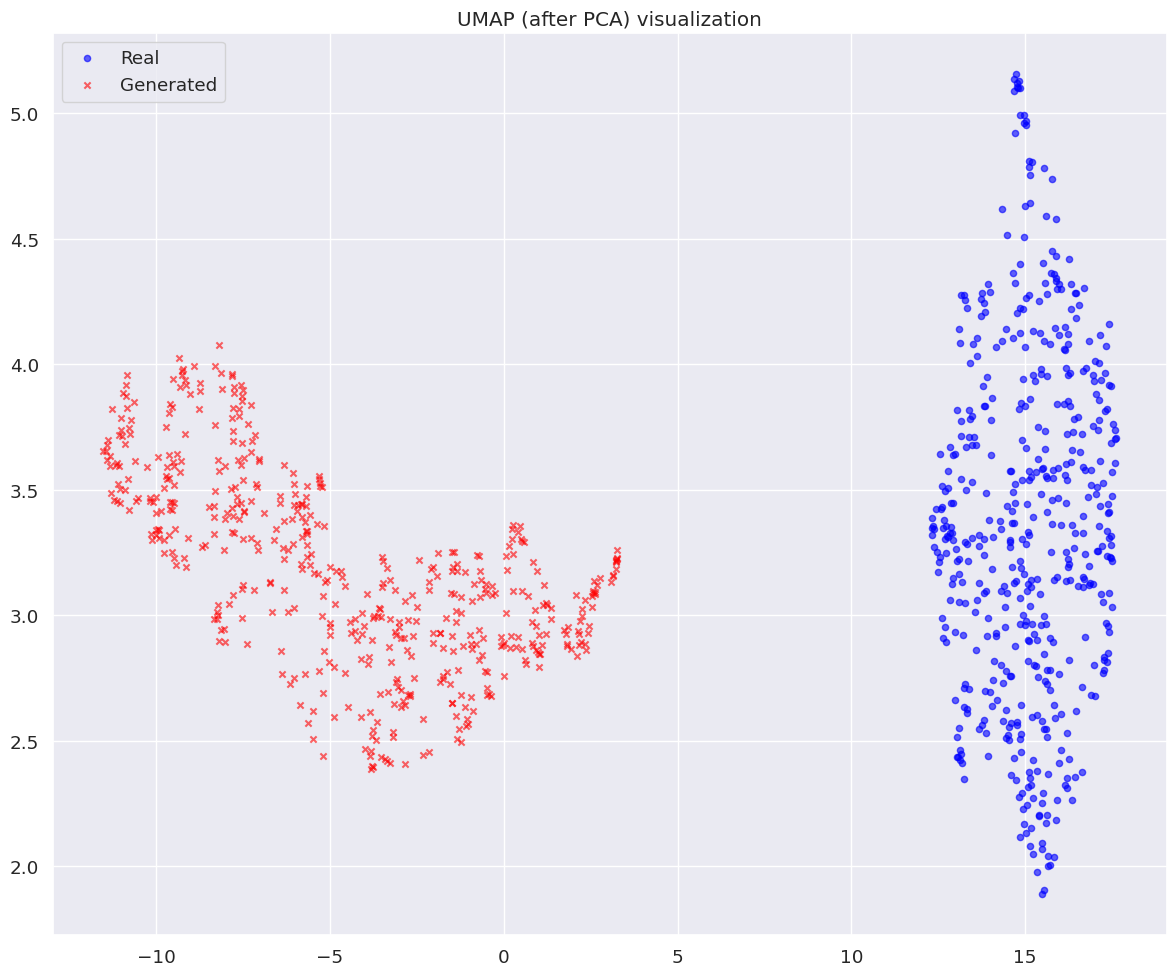

In [ ]:
from sklearn.decomposition import PCA

def visualize_umap_with_pca(generator, dataloader, device, latent_size, num_images=500, pca_components=50):
    """
    Более быстрая версия: сначала PCA до 50 компонент, затем UMAP.
    """
    generator.eval()

    # Сбор данных (как выше)
    real_images_list = []
    for real_batch, _ in dataloader:
        real_images_list.append(real_batch)
        if len(real_images_list) * real_batch.size(0) >= num_images:
            break
    real_images = torch.cat(real_images_list, dim=0)[:num_images]
    n_real = len(real_images)

    with torch.no_grad():
        z = torch.randn(num_images, latent_size, 1, 1, device=device)
        fake_images = generator(z).cpu()

    real_flat = real_images.view(n_real, -1).numpy()
    fake_flat = fake_images.view(num_images, -1).numpy()
    X = np.vstack([real_flat, fake_flat])
    y = np.hstack([np.ones(n_real), np.zeros(num_images)])

    # PCA
    print(f"PCA: уменьшаем размерность с {X.shape[1]} до {pca_components}...")
    pca = PCA(n_components=pca_components, random_state=42)
    X_pca = pca.fit_transform(X)
    print(f"PCA объясняет {pca.explained_variance_ratio_.sum()*100:.1f}% дисперсии")

    # UMAP
    print("Запуск UMAP...")
    reducer = umap.UMAP(n_components=2, random_state=42, verbose=True)
    X_umap = reducer.fit_transform(X_pca)

    # Визуализация
    plt.figure(figsize=(12, 10))
    plt.scatter(X_umap[y == 1, 0], X_umap[y == 1, 1],
                c='blue', marker='o', alpha=0.6, s=20, label='Real')
    plt.scatter(X_umap[y == 0, 0], X_umap[y == 0, 1],
                c='red', marker='x', alpha=0.6, s=20, label='Generated')
    plt.legend()
    plt.title('UMAP (after PCA) visualization')
    plt.tight_layout()
    plt.show()

    return X_umap, y

# Запуск
X_umap, y_labels = visualize_umap_with_pca(
    generator=model["generator"],
    dataloader=dataloader,
    device=device,
    latent_size=latent_size,
    num_images=500,
    pca_components=50
)

**WGAN-GP**

In [ ]:
accuracy_cv = evaluate_1nn_cv(
    generator=model["generator"],
    dataloader=dataloader,
    device=device,
    latent_size=latent_size,
    num_images=500,
    cv_folds=5
)

1-NN 5-fold CV Accuracy: 1.0000 ± 0.0000


PCA: уменьшаем размерность с 49152 до 50...
PCA объясняет дисперсию: 0.93
Запуск t-SNE...


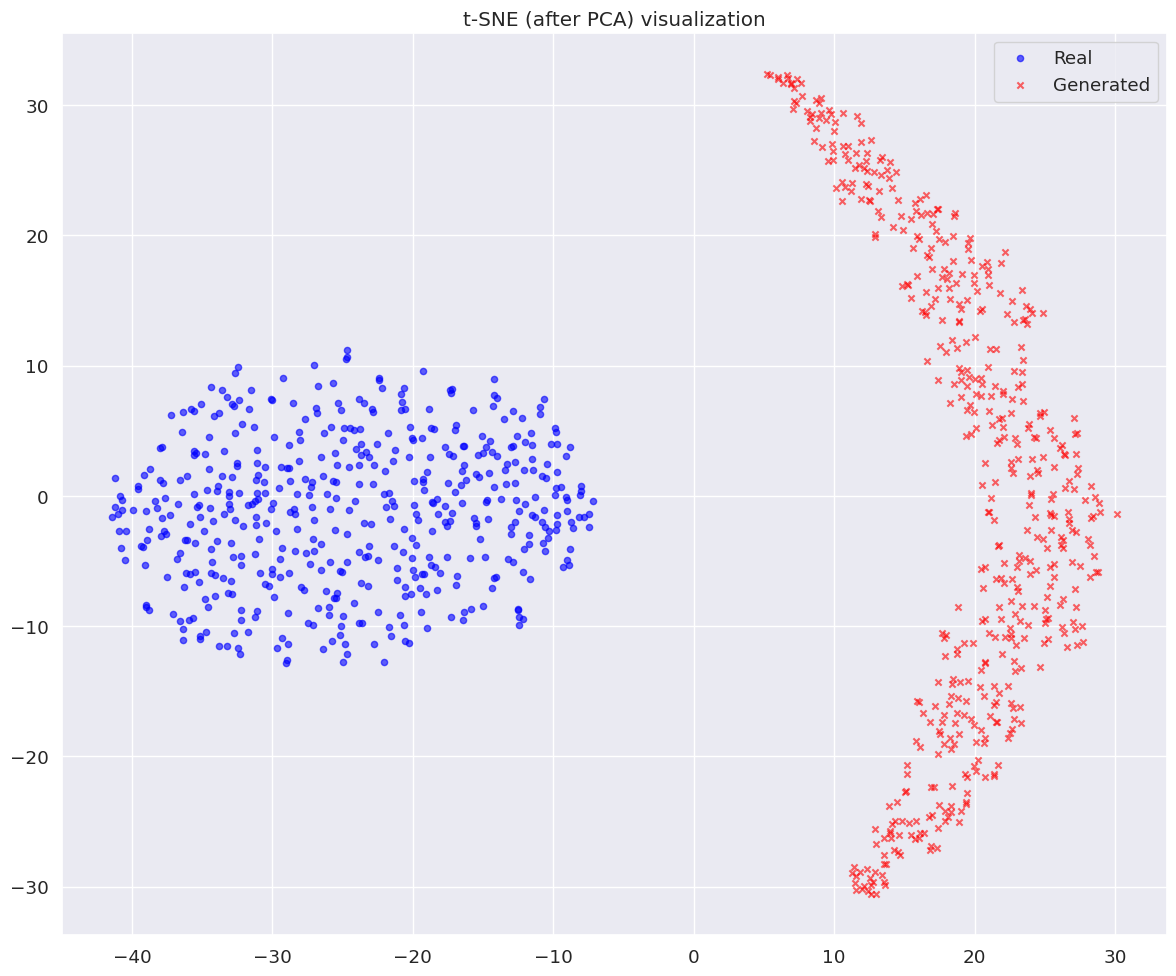

In [ ]:
X_tsne, y_labels = visualize_tsne_with_pca(
    generator=model["generator"],
    dataloader=dataloader,
    device=device,
    latent_size=latent_size,
    num_images=500,
    pca_components=50
)

PCA: уменьшаем размерность с 49152 до 50...
PCA объясняет 93.4% дисперсии
Запуск UMAP...
UMAP(n_jobs=1, random_state=42, verbose=True)
Wed May 27 15:28:10 2026 Construct fuzzy simplicial set


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Wed May 27 15:28:12 2026 Finding Nearest Neighbors
Wed May 27 15:28:12 2026 Finished Nearest Neighbor Search
Wed May 27 15:28:12 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Wed May 27 15:28:16 2026 Finished embedding


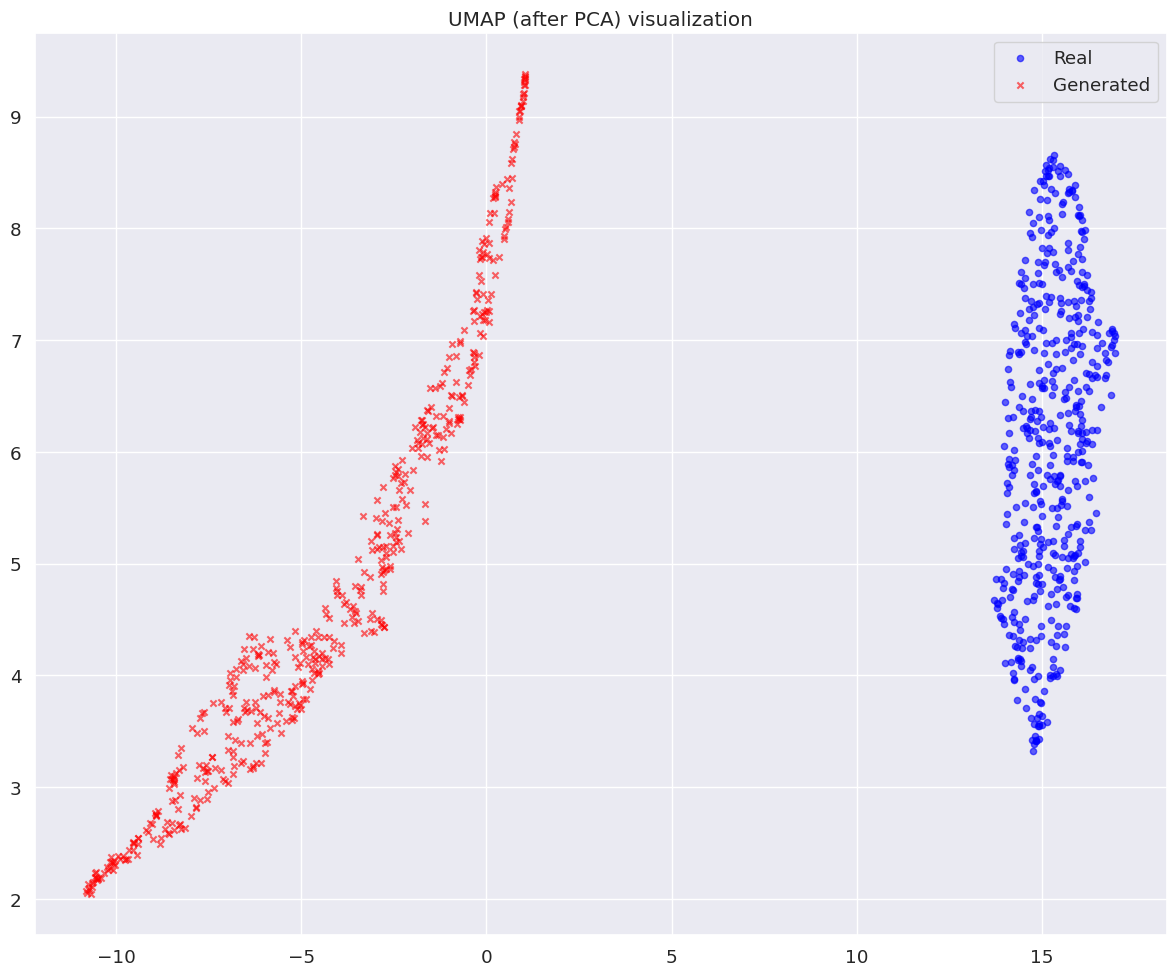

In [ ]:
X_umap, y_labels = visualize_umap_with_pca(
    generator=model["generator"],
    dataloader=dataloader,
    device=device,
    latent_size=latent_size,
    num_images=500,
    pca_components=50
)

**StyleGAN‑2**

In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneOut
import torch
from tqdm.notebook import tqdm

def compute_1nn_loo_accuracy(generator, dataloader, device, latent_dim=512, num_samples=500):
    """
    Вычисляет Leave-One-Out 1-NN accuracy для оценки качества генерации.

    Args:
        generator: обученный генератор StyleGAN-2
        dataloader: DataLoader с реальными изображениями
        device: cuda/cpu
        latent_dim: размерность латентного вектора (для StyleGAN-2 обычно 512)
        num_samples: количество изображений для оценки (чем больше, тем точнее)

    Returns:
        accuracy: float (чем ближе к 0.5, тем лучше)
    """
    generator.eval()

    # 1. Собираем реальные изображения
    real_images = []
    for real_batch, _ in tqdm(dataloader, desc="Loading real images"):
        real_images.append(real_batch)
        if len(real_images) * real_batch.size(0) >= num_samples:
            break
    real_images = torch.cat(real_images, dim=0)[:num_samples]
    real_images = real_images.cpu()
    n_real = len(real_images)
    print(f"Загружено {n_real} реальных изображений")

    # 2. Генерируем столько же фейковых
    with torch.no_grad():
        z = torch.randn(n_real, latent_dim, device=device)
        fake_images = generator(z).cpu()
    print(f"Сгенерировано {len(fake_images)} фейковых изображений")

    # 3. Превращаем в плоские векторы (flatten)
    real_flat = real_images.view(n_real, -1).numpy()
    fake_flat = fake_images.view(n_real, -1).numpy()

    # 4. Объединяем и создаём метки
    X = np.vstack([real_flat, fake_flat])
    y = np.hstack([np.ones(n_real), np.zeros(n_real)])

    # 5. Leave-One-Out кросс-валидация (только для небольших выборок)
    # Если num_samples > 500, используем k-fold вместо LOO
    if n_real > 500:
        print("Используем 10-fold CV вместо LOO (слишком много данных)...")
        from sklearn.model_selection import cross_val_score
        from sklearn.model_selection import StratifiedKFold
        knn = KNeighborsClassifier(n_neighbors=1)
        cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
        scores = cross_val_score(knn, X, y, cv=cv, scoring='accuracy')
        accuracy = scores.mean()
        print(f"10-fold CV Accuracy: {accuracy:.4f} ± {scores.std():.4f}")
    else:
        # Настоящий LOO
        loo = LeaveOneOut()
        knn = KNeighborsClassifier(n_neighbors=1)
        correct = 0
        total = 0

        print("Выполняется Leave-One-Out...")
        for train_idx, test_idx in tqdm(loo.split(X), total=len(X)):
            knn.fit(X[train_idx], y[train_idx])
            pred = knn.predict(X[test_idx])
            if pred[0] == y[test_idx][0]:
                correct += 1
            total += 1

        accuracy = correct / total

    print(f"\n=== РЕЗУЛЬТАТ ===")
    print(f"1-NN Leave-One-Out Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Идеальное значение: 0.5 (50%) — распределения неразличимы")
    return accuracy

# Запуск (после обучения)
accuracy = compute_1nn_loo_accuracy(
    generator=trainer.GAN.G,  # генератор StyleGAN-2
    dataloader=trainer.dl,    # DataLoader из тренировщика
    device=trainer.device,
    latent_dim=512,
    num_samples=500           # можно увеличить до 1000, но будет дольше
)

NameError: name 'trainer' is not defined

In [ ]:
def visualize_tsne(generator, dataloader, device, latent_dim=512, num_samples=500, perplexity=30):
    """
    Визуализирует распределения реальных и сгенерированных изображений с помощью t-SNE.
    """
    generator.eval()

    # Сбор реальных изображений
    real_images = []
    for real_batch, _ in dataloader:
        real_images.append(real_batch)
        if len(real_images) * real_batch.size(0) >= num_samples:
            break
    real_images = torch.cat(real_images, dim=0)[:num_samples].cpu()
    n_real = len(real_images)

    # Генерация фейковых
    with torch.no_grad():
        z = torch.randn(n_real, latent_dim, device=device)
        fake_images = generator(z).cpu()

    # Flatten
    real_flat = real_images.view(n_real, -1).numpy()
    fake_flat = fake_images.view(n_real, -1).numpy()
    X = np.vstack([real_flat, fake_flat])
    y = np.hstack([np.ones(n_real), np.zeros(n_real)])

    # t-SNE
    print("Запуск t-SNE (может занять 2-3 минуты)...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, init='random', learning_rate='auto')
    X_tsne = tsne.fit_transform(X)

    # Визуализация
    plt.figure(figsize=(12, 10))
    plt.scatter(X_tsne[y == 1, 0], X_tsne[y == 1, 1],
                c='blue', marker='o', alpha=0.5, s=15, label='Real Images')
    plt.scatter(X_tsne[y == 0, 0], X_tsne[y == 0, 1],
                c='red', marker='x', alpha=0.5, s=15, label='Generated Images')
    plt.legend(fontsize=12)
    plt.title(f't-SNE Visualization (perplexity={perplexity})', fontsize=14)
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return X_tsne, y

# Запуск
X_tsne, y_tsne = visualize_tsne(
    generator=trainer.GAN.G,
    dataloader=trainer.dl,
    device=trainer.device,
    latent_dim=512,
    num_samples=500,
    perplexity=30
)

NameError: name 'trainer' is not defined

In [ ]:
def visualize_umap(generator, dataloader, device, latent_dim=512, num_samples=500, n_neighbors=15, min_dist=0.1):
    """
    Визуализирует распределения с помощью UMAP (быстрее t-SNE, лучше сохраняет глобальную структуру).
    """
    generator.eval()

    # Сбор данных (как выше)
    real_images = []
    for real_batch, _ in dataloader:
        real_images.append(real_batch)
        if len(real_images) * real_batch.size(0) >= num_samples:
            break
    real_images = torch.cat(real_images, dim=0)[:num_samples].cpu()
    n_real = len(real_images)

    with torch.no_grad():
        z = torch.randn(n_real, latent_dim, device=device)
        fake_images = generator(z).cpu()

    real_flat = real_images.view(n_real, -1).numpy()
    fake_flat = fake_images.view(n_real, -1).numpy()
    X = np.vstack([real_flat, fake_flat])
    y = np.hstack([np.ones(n_real), np.zeros(n_real)])

    # UMAP
    print("Запуск UMAP...")
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        random_state=42,
        metric='euclidean',
        verbose=True
    )
    X_umap = reducer.fit_transform(X)

    # Визуализация
    plt.figure(figsize=(12, 10))
    plt.scatter(X_umap[y == 1, 0], X_umap[y == 1, 1],
                c='blue', marker='o', alpha=0.5, s=15, label='Real Images')
    plt.scatter(X_umap[y == 0, 0], X_umap[y == 0, 1],
                c='red', marker='x', alpha=0.5, s=15, label='Generated Images')
    plt.legend(fontsize=12)
    plt.title(f'UMAP Visualization (n_neighbors={n_neighbors}, min_dist={min_dist})', fontsize=14)
    plt.xlabel('UMAP Component 1')
    plt.ylabel('UMAP Component 2')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return X_umap, y

# Запуск
X_umap, y_umap = visualize_umap(
    generator=trainer.GAN.G,
    dataloader=trainer.dl,
    device=trainer.device,
    latent_dim=512,
    num_samples=500,
    n_neighbors=15,
    min_dist=0.1
)

In [ ]:
def print_analysis(accuracy, X_tsne, y_tsne, X_umap, y_umap):
    """Выводит анализ качества генерации."""

    # Оценка перекрытия по t-SNE (приближённая)
    from sklearn.neighbors import NearestNeighbors

    # Разделяем точки по меткам
    real_tsne = X_tsne[y_tsne == 1]
    fake_tsne = X_tsne[y_tsne == 0]

    # Доля фейковых точек, у которых ближайший сосед — реальный (локальное перекрытие)
    nbrs = NearestNeighbors(n_neighbors=1).fit(real_tsne)
    distances, indices = nbrs.kneighbors(fake_tsne)
    overlap_ratio = (distances < 0.5).mean()  # эмпирический порог

    print("\n" + "="*50)
    print("АНАЛИЗ КАЧЕСТВА ГЕНЕРАЦИИ STYLEGAN-2")
    print("="*50)
    print(f"1-NN LOO Accuracy:      {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Локальное перекрытие (t-SNE): {overlap_ratio:.2%}")
    print("\nИнтерпретация:")
    if accuracy < 0.55:
        print("    Отлично! Распределения почти неразличимы.")
    elif accuracy < 0.65:
        print("    Хорошо. GAN выучил основную структуру данных.")
    elif accuracy < 0.80:
        print("    Средне. Есть заметные различия в распределениях.")
    else:
        print("    Плохо. Генератор не доучился или mode collapse.")

    if overlap_ratio > 0.3:
        print("    Точки на t-SNE сильно пересекаются — хорошее разнообразие.")
    else:
        print("    Точки почти не пересекаются — режим коллапс или недостаточное обучение.")

# Запуск анализа
print_analysis(accuracy, X_tsne, y_tsne, X_umap, y_umap)

**StyleGAN‑2-ADA**

In [ ]:
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt

def visualize_latent_space(generator, real_loader, device, num_samples=500, method='tsne'):
    """
    Визуализирует латентное пространство W с помощью t-SNE или UMAP.

    Args:
        generator: ваша модель генератора
        real_loader: DataLoader с реальными изображениями
        device: 'cuda' или 'cpu'
        num_samples: количество сэмплов для визуализации
        method: 'tsne' или 'umap'
    """
    print(f"Извлечение W-векторов для {num_samples} изображений...")

    # 1. Проецируем реальные изображения в W пространство (инверсия)
    # Для этого нужна функция проекции, но её нет в вашей реализации
    # Проще: генерируем случайные W векторы и отмечаем их
    w_vectors = []
    labels = []

    with torch.no_grad():
        generator.eval()

        # Генерируем случайные W векторы (создаем карту распределения)
        for i in range(num_samples):
            z = torch.randn(1, 512, device=device)
            w = generator.mapping(z)  # W вектор
            w_vectors.append(w.cpu().numpy().flatten())
            labels.append('generated')

        # Для реальных изображений нужна проекция через оптимизацию
        # Без проекции можно просто взять еще сгенерированных с разными параметрами
        for i in range(num_samples):
            z = torch.randn(1, 512, device=device)
            w = generator.mapping(z, truncation_psi=0.5)  # другой стиль
            w_vectors.append(w.cpu().numpy().flatten())
            labels.append('truncated')

    w_vectors = np.array(w_vectors)

    # 2. Применяем t-SNE или UMAP
    print(f"Вычисление {method.upper()}...")
    if method == 'tsne':
        reducer = TSNE(n_components=2, random_state=42, perplexity=30)
    else:
        reducer = umap.UMAP(n_components=2, random_state=42)

    embedded = reducer.fit_transform(w_vectors)

    # 3. Рисуем график
    plt.figure(figsize=(12, 10))
    unique_labels = list(set(labels))
    colors = ['blue', 'orange', 'green']

    for i, label in enumerate(unique_labels):
        mask = np.array(labels) == label
        plt.scatter(embedded[mask, 0], embedded[mask, 1],
                   c=colors[i % len(colors)], label=label, alpha=0.6, s=30)

    plt.title(f'{method.upper()} visualization of W latent space')
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    generator.train()

In [ ]:
visualize_latent_space(generator, dataloader, device, method='tsne')
visualize_latent_space(generator, dataloader, device, method='umap')

Прокомментируйте получившийся результат:

получившиеся результаты требуют доработки, как видно на граффиках большое растояние между точками, нет перемешанных точек. Проблема mode collapse